# **ANÁLISIS PREDICTIVO DEL TIEMPO DE TRÁNSITO DE LOS BUQUES EN EL CANAL DE PANAMÁ**


El objetivo central de este proyecto es desarrollar un modelo capaz de predecir con precisión el tiempo de tránsito de los buques, permitiendo una optimización proactiva de la logística interoceánica.

Para lograrlo, el notebook consolida un ecosistema de datos multidimensional que incluye:



*  El registro histórico de tránsitos y tiempos de espera (**transit.parquet**).
*  La trazabilidad operativa en las esclusas (**locks_visit.parquet**).
*  Las características técnicas y estructurales de las embarcaciones (**specs.parquet**).
*   Un conjunto de variables meteorológicas críticas (**clima_total_2015_2024**).

Al cruzar estos datasets, buscamos identificar cómo factores como el tipo de buque, su carga y las condiciones de viento y presión afectan la fluidez del paso, transformando datos históricos en una herramienta de inteligencia predictiva para la toma de decisiones.

## **EXTRACCIÓN Y LIMPIEZA DE DATOS**

Lo primero que haremos es extraer y convertir los datos de cada uno de los archivos en formato parquet a dataframes funcionales.

### **Transformación de los archivos de formato parquet a dataframes**

In [1]:
import os

# Ruta local a la carpeta de datasets
DATA_DIR = os.path.join(os.getcwd(), "datasets")

print("DATA_DIR:", DATA_DIR)
print("Archivos encontrados:", [f for f in os.listdir(DATA_DIR) if f.endswith((".parquet", ".csv"))])


DATA_DIR: c:\Users\jjjhe\OneDrive\Desktop\Maestría Analítica de Datos\Proyecto Integrador III\datasets
Archivos encontrados: ['climate-vars.csv', 'clima_total_2015_2024.csv', 'Gatun_Lake_Water_Level_History.csv', 'locks_visit.parquet', 'specs.parquet', 'transit.parquet']


In [2]:
import pandas as pd
import os

# Definimos los archivos que se leerán
specific_files = ['locks_visit.parquet', 'specs.parquet', 'transit.parquet']

# Inicializa un diccionario para almacenar los dataframes
dataframes = {}

# Lee cada archivo específico en un DataFrame
for fname in specific_files:
    file_path = os.path.join(DATA_DIR, fname)
    df = None

    try:
        # Intenta leer el archivo como Parquet
        df = pd.read_parquet(file_path)
        print(f"Archivo: {fname} leído como Parquet.")
    except Exception as e:
        print(f"Error al leer {fname} como Parquet: {e}")

    if df is not None:
        # Almacena el DataFrame en el diccionario
        dataframes[fname.replace('.parquet', '').replace('.csv', '')] = df

        # Muestra las primeras filas para confirmación
        display(df.head())

# Accedemos a los dataframes por sus nombres
locks_df = dataframes['locks_visit']
specs_df = dataframes['specs']
transit_df = dataframes['transit']

Archivo: locks_visit.parquet leído como Parquet.


,imo,mmsi,dt_pos_utc,Name,segr
0,2051.0,374001000.0,2019-01-01 00:00:00,Miraflores Locks Original,0
1,9534810.0,370313000.0,2019-01-01 00:00:20,Cocoli Locks,0
2,9377248.0,636013816.0,2019-01-01 00:00:55,Miraflores Locks Original,0
3,9397858.0,477133300.0,2019-01-01 00:01:05,Pedro Miguel Locks Original,0
4,9279989.0,352983000.0,2019-01-01 00:06:12,Cocoli Locks,0


Archivo: specs.parquet leído como Parquet.


,imo,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5
0,1000021,68.500,1980,484,3716.0,Oil,Yacht
1,1000150,41.930,291,0,397.0,Oil,Yacht (Sailing)
2,1001178,49.580,702,0,2700.0,Oil,Yacht
3,1002225,30.800,397,387,756.0,Oil,Yacht
4,1002342,38.625,489,0,1156.0,Oil,Yacht


Archivo: transit.parquet leído como Parquet.


,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
0,9717292.0,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,5.521111
1,9581239.0,1,South,Bulk carrier,2019-01-01 00:39:05,2019-01-02 02:41:17,2018-12-31 00:11:14,2018-12-31 23:09:29,0,22.970833,26.036667
2,9758038.0,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,5.790000
3,9369095.0,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,6.494167
4,9683398.0,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,6.130833


### **Transformación del archivo de clima csv a dataframe**

In [3]:
import pandas as pd
import os

clima_df = pd.read_csv(os.path.join(DATA_DIR, "climate-vars.csv"), encoding="latin1", sep=",")
display(clima_df.head())


,time,temperature_2m (Â°C),precipitation (mm),dew_point_2m (Â°C),relative_humidity_2m (%),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),visibility (m),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction_10m (Â°),wind_gusts_10m (km/h)
0,2019-01-01T00:00,24.5,0.0,22.8,91,42,18,13,28,NaN,0.29,11.5,346,23.4
1,2019-01-01T01:00,24.5,0.0,22.6,89,61,14,5,53,NaN,0.32,12.1,348,25.2
2,2019-01-01T02:00,24.5,0.0,22.5,89,67,13,0,61,NaN,0.35,12.9,347,27.0
3,2019-01-01T03:00,24.5,0.0,22.2,87,74,28,0,64,NaN,0.40,12.8,350,27.0
4,2019-01-01T04:00,24.6,0.0,22.3,87,83,42,1,71,NaN,0.40,12.1,348,26.3


In [4]:
display(df.head())

,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
0,9717292.0,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,5.521111
1,9581239.0,1,South,Bulk carrier,2019-01-01 00:39:05,2019-01-02 02:41:17,2018-12-31 00:11:14,2018-12-31 23:09:29,0,22.970833,26.036667
2,9758038.0,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,5.790000
3,9369095.0,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,6.494167
4,9683398.0,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,6.130833


### **Transformación del archivo del los niveles del lago gatun de csv a dataframe**

In [5]:
import os
gatun_level_df = pd.read_csv(os.path.join(DATA_DIR, "Gatun_Lake_Water_Level_History.csv"), sep=",")
display(gatun_level_df.head())


,DATE_LOG,GATUN_LAKE_LEVEL(FEET)
0,1965-01-01,86.49
1,1965-01-02,86.48
2,1965-01-03,86.47
3,1965-01-04,86.46
4,1965-01-05,86.42


### **Limpieza de datos de los dataframes**


#### **Limpieza de SPECS_DF**

##### **Revisamos los distintos tipos de datos**

In [6]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11793 entries, 0 to 11792
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11793 non-null  int64  
 1   LengthBetweenPerpendicularsLBP  11793 non-null  float64
 2   GrossTonnage                    11793 non-null  int64  
 3   Deadweight                      11793 non-null  int64  
 4   Powerkwmax                      11787 non-null  float64
 5   MainEngineType                  11789 non-null  object 
 6   ShiptypeLevel5                  11793 non-null  object 
dtypes: float64(2), int64(3), object(2)
memory usage: 645.1+ KB


In [7]:
print('Tipos de datos:')
display(specs_df.dtypes)

Tipos de datos:


imo                                 int64
LengthBetweenPerpendicularsLBP    float64
GrossTonnage                        int64
Deadweight                          int64
Powerkwmax                        float64
MainEngineType                     object
ShiptypeLevel5                     object
dtype: object

In [8]:
# Transformamos la variable imo a string debido a que es un código y no un número
specs_df["imo"] = specs_df["imo"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [9]:
print('Valores nulos por columna:')
display(specs_df.isnull().sum())

Valores nulos por columna:


imo                               0
LengthBetweenPerpendicularsLBP    0
GrossTonnage                      0
Deadweight                        0
Powerkwmax                        6
MainEngineType                    4
ShiptypeLevel5                    0
dtype: int64

Observamos los valores nulos en las columnas ***Powerkwmax*** y ***MainEngineType***. Vamos a trabjar en estrategías de imputación para ambos campos.

##### **Imputación de valores para MainEngineType**

Para este caso, vamos a utilizar 2 estrategías de imputación:

*  Primero, para cada valor de ShiptypeLevel5, calcularemos cuál es el MainEngineType más frecuente (la moda) dentro de ese tipo de buque y usaremos ese valor para rellenar solo los nulos de ese mismo grupo.

* Después, cualquier fila que siga nula (por ejemplo, porque en su grupo no había datos válidos para calcular moda) se eliminará.

In [10]:
# Imputar valores nulos en MainEngineType con la moda por ShiptypeLevel5
def imputar_moda_engine_type(df):
    df = df.copy()
    for shiptype in df['ShiptypeLevel5'].unique():
        mask = (df['ShiptypeLevel5'] == shiptype)
        moda = df.loc[mask, 'MainEngineType'].mode(dropna=True)
        if not moda.empty:
            df.loc[mask & df['MainEngineType'].isnull(), 'MainEngineType'] = moda[0]
    return df

specs_df = imputar_moda_engine_type(specs_df)

# Eliminar registros que aún tengan MainEngineType nulo después de la imputación
specs_df = specs_df[~specs_df['MainEngineType'].isnull()].reset_index(drop=True)

# Verificar que ya no hay nulos en MainEngineType
display(specs_df['MainEngineType'].isnull().sum())

np.int64(0)

##### **Imputación de valores para Powerkwmax**

En este caso, vamos a buscar la media del grupo más específico (MainEngineType + ShiptypeLevel5) y, si no existe suficiente dato en ese cruce, cae a una media más general solo por ShiptypeLevel5.

In [11]:
# Imputar valores nulos en Powerkwmax
import numpy as np

def imputar_media_powerkwmax(df):
    df = df.copy()
    mask_nulo = df['Powerkwmax'].isnull()
    for idx in df[mask_nulo].index:
        engine = df.at[idx, 'MainEngineType']
        shiptype = df.at[idx, 'ShiptypeLevel5']
        # Media por MainEngineType y ShiptypeLevel5
        media1 = df[(df['MainEngineType'] == engine) & (df['ShiptypeLevel5'] == shiptype)]['Powerkwmax'].mean()
        if not np.isnan(media1):
            df.at[idx, 'Powerkwmax'] = media1
        else:
            # Media por ShiptypeLevel5
            media2 = df[df['ShiptypeLevel5'] == shiptype]['Powerkwmax'].mean()
            if not np.isnan(media2):
                df.at[idx, 'Powerkwmax'] = media2
    return df

specs_df = imputar_media_powerkwmax(specs_df)

# Confirmar que no quedan nulos en Powerkwmax
display(specs_df['Powerkwmax'].isnull().sum())

np.int64(0)

In [12]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11791 entries, 0 to 11790
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11791 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11791 non-null  float64
 2   GrossTonnage                    11791 non-null  int64  
 3   Deadweight                      11791 non-null  int64  
 4   Powerkwmax                      11791 non-null  float64
 5   MainEngineType                  11791 non-null  object 
 6   ShiptypeLevel5                  11791 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 644.9+ KB


In [13]:
specs_df

,imo,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5
0,1000021,68.500,1980,484,3716.0,Oil,Yacht
1,1000150,41.930,291,0,397.0,Oil,Yacht (Sailing)
2,1001178,49.580,702,0,2700.0,Oil,Yacht
3,1002225,30.800,397,387,756.0,Oil,Yacht
4,1002342,38.625,489,0,1156.0,Oil,Yacht
...,...,...,...,...,...,...,...
11786,9965851,196.800,36091,64611,7080.0,Oil,Bulk Carrier
11787,9966087,197.000,36412,64028,6940.0,Oil,Bulk Carrier
11788,9966104,178.000,24386,40020,5650.0,Oil,Bulk Carrier
11789,9973420,174.000,23759,37359,5400.0,Oil,Bulk Carrier


In [14]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11791 entries, 0 to 11790
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11791 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11791 non-null  float64
 2   GrossTonnage                    11791 non-null  int64  
 3   Deadweight                      11791 non-null  int64  
 4   Powerkwmax                      11791 non-null  float64
 5   MainEngineType                  11791 non-null  object 
 6   ShiptypeLevel5                  11791 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 644.9+ KB


##### **Limpieza de outliers**

Limpiaremos los outliers; comenzaremos eliminando aquellos valores negativos o cero (0) de las variables:

* ***LengthBetweenPerpendicularsLBP***
* ***GrossTonnage***
* ***Deadweight***
* ***Powerkwmax***

Estas variables representan medidas físicas del buque o de su capacidad y, por lógica operativa, no deberían ser 0 si el registro corresponde a una embarcación real en servicio.

In [15]:
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

# Eliminar valores no válidos: 0 o negativos
specs_df = specs_df[
    (specs_df["LengthBetweenPerpendicularsLBP"] > 0) &
    (specs_df["GrossTonnage"] > 0) &
    (specs_df["Deadweight"] > 0) &
    (specs_df["Powerkwmax"] > 0)
].copy()

print("Filas luego de eliminar 0 y negativos:", len(specs_df))

Filas luego de eliminar 0 y negativos: 11522


Ahora procedemos a detectar y eliminar las variables de las outliers utilizando el metodo de IQR para cada una de las columnas previamente vistas.

In [16]:
print('Valores mínimos y máximos de las variables seleccionadas:')
print(f"LengthBetweenPerpendicularsLBP: Min = {specs_df['LengthBetweenPerpendicularsLBP'].min()}, Max = {specs_df['LengthBetweenPerpendicularsLBP'].max()}")
print(f"GrossTonnage: Min = {specs_df['GrossTonnage'].min()}, Max = {specs_df['GrossTonnage'].max()}")
print(f"Deadweight: Min = {specs_df['Deadweight'].min()}, Max = {specs_df['Deadweight'].max()}")
print(f"Powerkwmax: Min = {specs_df['Powerkwmax'].min()}, Max = {specs_df['Powerkwmax'].max()}")

print('\nLímites Inferiores y Superiores (IQR):')
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

for col in cols:
    Q1 = specs_df[col].quantile(0.25)
    Q3 = specs_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col}: Inferior = {lower_bound:.2f}, Superior = {upper_bound:.2f}")

Valores mínimos y máximos de las variables seleccionadas:
LengthBetweenPerpendicularsLBP: Min = 16.6, Max = 383.0
GrossTonnage: Min = 56, Max = 203949
Deadweight: Min = 4, Max = 398199
Powerkwmax: Min = 228.0, Max = 80905.0

Límites Inferiores y Superiores (IQR):
LengthBetweenPerpendicularsLBP: Inferior = 97.00, Superior = 297.00
GrossTonnage: Inferior = -9203.62, Superior = 76307.38
Deadweight: Inferior = -35707.12, Superior = 137855.88
Powerkwmax: Inferior = -1175.00, Superior = 21105.00


In [17]:
cols_with_bounds = {
    "GrossTonnage": {"lower": -9203.62, "upper": 76307.38},
    "Deadweight": {"lower": -35707.12, "upper": 137855.88},
    "Powerkwmax": {"lower": -1175.00, "upper": 21105.00}
}

total_lost_rows = 0
print("Número de filas fuera de los límites para cada variable:")
for col, bounds in cols_with_bounds.items():
    lower = bounds["lower"]
    upper = bounds["upper"]
    lost_for_col = specs_df[(specs_df[col] < lower) | (specs_df[col] > upper)].shape[0]
    print(f"- {col}: {lost_for_col} filas perdidas")
    total_lost_rows += lost_for_col

print(f"\nTotal de filas perdidas fuera de los límites especificados: {total_lost_rows}")

Número de filas fuera de los límites para cada variable:
- GrossTonnage: 1257 filas perdidas
- Deadweight: 495 filas perdidas
- Powerkwmax: 1469 filas perdidas

Total de filas perdidas fuera de los límites especificados: 3221


In [18]:
specs_df.describe()

,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax
count,11522.000000,11522.000000,11522.000000,11522.000000
mean,191.666255,38761.368946,54002.619511,13500.887612
std,57.241560,28239.268301,37817.574599,13570.132027
min,16.600000,56.000000,4.000000,228.000000
25%,172.000000,22863.000000,29379.000000,7180.000000
50%,185.000000,32287.000000,49999.000000,8990.000000
75%,222.000000,44240.750000,72769.750000,12750.000000
max,383.000000,203949.000000,398199.000000,80905.000000


In [19]:
print('\nLímites Inferiores y Superiores (IQR):')
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

for col in cols:
    Q1 = specs_df[col].quantile(0.25)
    Q3 = specs_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col}: Inferior = {lower_bound:.2f}, Superior = {upper_bound:.2f}")


Límites Inferiores y Superiores (IQR):
LengthBetweenPerpendicularsLBP: Inferior = 97.00, Superior = 297.00
GrossTonnage: Inferior = -9203.62, Superior = 76307.38
Deadweight: Inferior = -35707.12, Superior = 137855.88
Powerkwmax: Inferior = -1175.00, Superior = 21105.00


In [20]:
# cols = ["GrossTonnage", "Deadweight", "Powerkwmax"]
# min_obs = 30

# rows_to_drop = []
# summary = []

# keep_mask = pd.Series(True, index=specs_df.index)

# for col in cols:
#     Q1 = specs_df[col].quantile(0.25)
#     Q3 = specs_df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     keep_mask &= specs_df[col].between(lower, upper, inclusive="both")

# removed = (~keep_mask).sum()
# rows_to_drop.extend(specs_df.index[~keep_mask].tolist())
# summary.append(("total", len(specs_df), int(removed), "procesado"))

# specs_df_no_outliers = specs_df.drop(index=rows_to_drop).copy()

# summary_df = pd.DataFrame(summary, columns=["grupo", "n_grupo", "filas_eliminadas", "estado"])

# display(summary_df.sort_values("filas_eliminadas", ascending=False))

# print("Filas originales:", len(specs_df))
# print("Filas sin outliers:", len(specs_df_no_outliers))
# print("Filas eliminadas:", len(specs_df) - len(specs_df_no_outliers))

In [21]:
# specs_df = specs_df_no_outliers

In [22]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11522 entries, 0 to 11790
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11522 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11522 non-null  float64
 2   GrossTonnage                    11522 non-null  int64  
 3   Deadweight                      11522 non-null  int64  
 4   Powerkwmax                      11522 non-null  float64
 5   MainEngineType                  11522 non-null  object 
 6   ShiptypeLevel5                  11522 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 720.1+ KB


#### **Limpieza de TRANSIT_DF**

##### **Revisamos los distintos tipos de datos**

In [23]:
transit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50933 entries, 0 to 50932
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   imo                 50920 non-null  float64       
 1   neo_transit         50933 non-null  int64         
 2   transit_bound       50933 non-null  object        
 3   vessel_type         50933 non-null  object        
 4   time_at_entrance    50933 non-null  datetime64[us]
 5   time_out_canal      50927 non-null  datetime64[us]
 6   time_anchoring_in   48952 non-null  datetime64[us]
 7   time_anchoring_out  48952 non-null  datetime64[us]
 8   direct_transit      50933 non-null  int32         
 9   waiting_time        48952 non-null  float64       
 10  transit_time        50927 non-null  float64       
dtypes: datetime64[us](4), float64(3), int32(1), int64(1), object(2)
memory usage: 4.1+ MB


In [24]:
transit_df.describe()

,imo,neo_transit,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
count,5.092000e+04,50933.000000,50933,50927,48952,48952,50933.000000,48952.000000,50927.000000
mean,9.508686e+06,0.258300,2021-06-12 07:59:29.622072,2021-06-12 17:13:20.113162,2021-05-13 00:57:06.410708,2021-05-14 17:41:17.395857,0.505095,40.736385,11.141819
min,1.000021e+06,0.000000,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:29,2018-12-31 22:35:13,0.000000,0.000000,-117.793611
25%,9.339334e+06,0.000000,2020-03-08 17:17:20,2020-03-09 03:07:10,2020-02-19 04:18:50.500000,2020-02-21 07:09:49.750000,0.000000,8.500000,7.350278
50%,9.515932e+06,0.000000,2021-05-28 05:42:26,2021-05-28 15:12:42,2021-04-23 03:14:13.500000,2021-04-24 05:46:53.500000,1.000000,21.475000,8.533889
75%,9.730878e+06,1.000000,2022-10-18 23:32:41,2022-10-19 06:01:13.500000,2022-08-12 02:10:00,2022-08-13 22:07:30,1.000000,48.666667,10.646389
max,9.974589e+06,1.000000,2023-10-31 22:33:53,2023-11-01 05:36:05,2023-10-31 08:20:00,2023-10-31 21:20:00,1.000000,1880.833333,2961.572222
std,3.655298e+05,0.437704,NaN,NaN,NaN,NaN,0.499979,55.972301,22.982345


In [25]:
print('Tipos de datos:')
display(transit_df.dtypes)

Tipos de datos:


imo                          float64
neo_transit                    int64
transit_bound                 object
vessel_type                   object
time_at_entrance      datetime64[us]
time_out_canal        datetime64[us]
time_anchoring_in     datetime64[us]
time_anchoring_out    datetime64[us]
direct_transit                 int32
waiting_time                 float64
transit_time                 float64
dtype: object

In [26]:
# Transformamos la variable imo a string debido a que es un codigo y no un número
transit_df["imo"] = transit_df["imo"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [27]:
print('Valores nulos por columna:')
display(transit_df.isnull().sum())

Valores nulos por columna:


imo                      0
neo_transit              0
transit_bound            0
vessel_type              0
time_at_entrance         0
time_out_canal           6
time_anchoring_in     1981
time_anchoring_out    1981
direct_transit           0
waiting_time          1981
transit_time             6
dtype: int64

##### **Eliminación de valores nulos para waiting_time, imo o transit_time nulos**

Eliminamos los valores de imo, waiting_time y transit_time nulos debido a que las cantidades son poco significativas en comparación de la totalidad de los datos (solamente representan 3% de la totalidad de datos).

In [28]:
# Eliminar registros con waiting_time, imo o transit_time nulos
transit_df = transit_df[
    transit_df["waiting_time"].notna() &
    transit_df["imo"].notna() &
    transit_df["transit_time"].notna()
].copy()

# Verificación
print("Filas restantes:", len(transit_df))
print("Nulos en waiting_time:", transit_df["waiting_time"].isna().sum())
print("Nulos en imo:", transit_df["imo"].isna().sum())
print("Nulos en transit_time:", transit_df["transit_time"].isna().sum())

Filas restantes: 48950
Nulos en waiting_time: 0
Nulos en imo: 0
Nulos en transit_time: 0


In [29]:
print(f"Valor mínimo de waiting_time: {transit_df['waiting_time'].min():.2f} horas")
print(f"Valor mínimo de transit_time: {transit_df['transit_time'].min():.2f} horas")

Valor mínimo de waiting_time: 0.00 horas
Valor mínimo de transit_time: 4.19 horas


##### **Manejo de outliers**

Manejamos los outliers de waiting_time y transit_time con el método de IQR. Aquellos valores que estén por encima de los límites, se eliminan.

In [30]:
# Eliminar outliers superiores en waiting_time y transit_time con método IQR (1.5)
cols_outliers = ["waiting_time", "transit_time"]

keep_mask = pd.Series(True, index=transit_df.index)
resumen = []

for col in cols_outliers:
    q1 = transit_df[col].quantile(0.25)
    q3 = transit_df[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr

    # 1. Conservar solo los elementos menores o iguales al límite superior
    mask_col = transit_df[col] <= upper
    keep_mask &= mask_col

    resumen.append({
        "columna": col,
        "q1": q1,
        "q3": q3,
        "limite_superior": upper,
        "outliers_columna": int((~mask_col).sum())  # Outliers detectados en ESTA columna
    })

transit_df_no_outliers = transit_df.loc[keep_mask].copy()
transit_df = transit_df_no_outliers  # Sobrescribe el dataset limpio

display(pd.DataFrame(resumen))
print(f"Filas originales: {len(keep_mask)}")
print(f"Filas sin outliers: {len(transit_df)}")
print(f"Total de filas eliminadas (combinado): {int((~keep_mask).sum())}\n")

# 2. Imprimir de forma separada los outliers de waiting_time y transit_time
print("--- Detalle de elementos eliminados por superar el límite superior ---")
for r in resumen:
    print(f"Eliminados en '{r['columna']}': {r['outliers_columna']}")

,columna,q1,q3,limite_superior,outliers_columna
0,waiting_time,8.500000,48.666667,108.916667,4732
1,transit_time,7.314444,10.481250,15.231458,7112


Filas originales: 48950
Filas sin outliers: 38491
Total de filas eliminadas (combinado): 10459

--- Detalle de elementos eliminados por superar el límite superior ---
Eliminados en 'waiting_time': 4732
Eliminados en 'transit_time': 7112


In [31]:
print(f"Valor mínimo de waiting_time: {transit_df['waiting_time'].min():.2f} horas")
print(f"Valor mínimo de transit_time: {transit_df['transit_time'].min():.2f} horas")

Valor mínimo de waiting_time: 0.00 horas
Valor mínimo de transit_time: 4.19 horas


In [32]:
# Validamos el dataframe
transit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38491 entries, 0 to 50932
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   imo                 38491 non-null  object        
 1   neo_transit         38491 non-null  int64         
 2   transit_bound       38491 non-null  object        
 3   vessel_type         38491 non-null  object        
 4   time_at_entrance    38491 non-null  datetime64[us]
 5   time_out_canal      38491 non-null  datetime64[us]
 6   time_anchoring_in   38491 non-null  datetime64[us]
 7   time_anchoring_out  38491 non-null  datetime64[us]
 8   direct_transit      38491 non-null  int32         
 9   waiting_time        38491 non-null  float64       
 10  transit_time        38491 non-null  float64       
dtypes: datetime64[us](4), float64(2), int32(1), int64(1), object(3)
memory usage: 3.4+ MB


In [33]:
transit_df.describe()

,neo_transit,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
count,38491.000000,38491,38491,38491,38491,38491.000000,38491.000000,38491.000000
mean,0.206646,2021-04-25 02:48:14.720454,2021-04-25 11:19:36.859811,2021-04-23 22:06:41.583019,2021-04-25 00:07:36.039359,0.505859,26.015127,8.522816
min,0.000000,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:40,2018-12-31 22:35:13,0.000000,0.000000,4.190556
25%,0.000000,2020-02-01 03:28:58,2020-02-01 09:34:33.500000,2020-01-30 16:29:41.500000,2020-01-31 19:40:52,0.000000,7.822917,7.134861
50%,0.000000,2021-03-30 14:06:57,2021-03-30 23:10:29,2021-03-29 16:48:03,2021-03-30 10:34:08,1.000000,18.510000,8.119722
75%,0.000000,2022-07-23 07:16:32.500000,2022-07-23 15:27:19.500000,2022-07-22 01:55:00,2022-07-23 02:00:00,1.000000,36.333333,9.311389
max,1.000000,2023-10-31 22:33:53,2023-11-01 05:36:05,2023-10-31 08:20:00,2023-10-31 21:20:00,1.000000,108.910000,15.230556
std,0.404904,NaN,NaN,NaN,NaN,0.499972,24.307843,1.959347


#### **Limpieza de LOCKS_DF**

##### **Revisamos los distintos tipos de datos**

In [34]:
locks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1226806 entries, 0 to 1226805
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   imo         497268 non-null   float64
 1   mmsi        1226323 non-null  float64
 2   dt_pos_utc  1226806 non-null  object 
 3   Name        1226806 non-null  object 
 4   segr        1226806 non-null  int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 46.8+ MB


In [35]:
print('Tipos de datos:')
display(locks_df.dtypes)


Tipos de datos:


imo           float64
mmsi          float64
dt_pos_utc     object
Name           object
segr            int64
dtype: object

In [36]:
# Transformamos la variable imo a string debido a que es un código y no un número
locks_df["imo"] = locks_df["imo"].astype("Int64").astype(str)
locks_df["mmsi"] = locks_df["mmsi"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [37]:
print('Valores nulos por columna antes de la eliminación:')
display(locks_df.isnull().sum())

Valores nulos por columna antes de la eliminación:


imo           0
mmsi          0
dt_pos_utc    0
Name          0
segr          0
dtype: int64

##### **Eliminamos los valores nulos de imo y mmsi**

Eliminamos los registros donde imo y mmsi son nulos debido a que estos registros son únicos.

In [38]:
# Eliminar filas donde 'imo' es null
locks_df = locks_df.dropna(subset=['imo'])
locks_df = locks_df.dropna(subset=['mmsi'])

print('\nValores nulos por columna después de eliminar nulos en imo:')
display(locks_df.isnull().sum())



Valores nulos por columna después de eliminar nulos en imo:


imo           0
mmsi          0
dt_pos_utc    0
Name          0
segr          0
dtype: int64

#### **Limpieza de CLIMA_DF**

##### **Revisamos los distintos tipos de datos**

In [39]:
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   time                           43824 non-null  object 
 1   temperature_2m (Â°C)           43824 non-null  float64
 2   precipitation (mm)             43824 non-null  float64
 3   dew_point_2m (Â°C)             43824 non-null  float64
 4   relative_humidity_2m (%)       43824 non-null  int64  
 5   cloud_cover (%)                43824 non-null  int64  
 6   cloud_cover_low (%)            43824 non-null  int64  
 7   cloud_cover_mid (%)            43824 non-null  int64  
 8   cloud_cover_high (%)           43824 non-null  int64  
 9   visibility (m)                 24341 non-null  float64
 10  vapour_pressure_deficit (kPa)  43824 non-null  float64
 11  wind_speed_10m (km/h)          43824 non-null  float64
 12  wind_direction_10m (Â°)        43824 non-null 

In [40]:
print('Tipos de datos:')
display(clima_df.dtypes)


Tipos de datos:


time                              object
temperature_2m (Â°C)             float64
precipitation (mm)               float64
dew_point_2m (Â°C)               float64
relative_humidity_2m (%)           int64
cloud_cover (%)                    int64
cloud_cover_low (%)                int64
cloud_cover_mid (%)                int64
cloud_cover_high (%)               int64
visibility (m)                   float64
vapour_pressure_deficit (kPa)    float64
wind_speed_10m (km/h)            float64
wind_direction_10m (Â°)            int64
wind_gusts_10m (km/h)            float64
dtype: object

##### **Revisamos los valores nulos**

In [41]:
print('Valores nulos por columna antes de la eliminación:')
display(clima_df.isnull().sum())

Valores nulos por columna antes de la eliminación:


time                                 0
temperature_2m (Â°C)                 0
precipitation (mm)                   0
dew_point_2m (Â°C)                   0
relative_humidity_2m (%)             0
cloud_cover (%)                      0
cloud_cover_low (%)                  0
cloud_cover_mid (%)                  0
cloud_cover_high (%)                 0
visibility (m)                   19483
vapour_pressure_deficit (kPa)        0
wind_speed_10m (km/h)                0
wind_direction_10m (Â°)              0
wind_gusts_10m (km/h)                0
dtype: int64

 ##### **Transformamos los datos de las columnas para facilidad de análisis**

Se realiza una estandarización del conjunto climático para asegurar consistencia antes del análisis: primero, se unifica la nomenclatura renombrando la columna año a periodo cuando está presente, luego se normalizan los nombres de todas las variables a minúsculas para evitar errores por diferencias de formato y, finalmente, se crea una copia operativa del dataset (clima) que será utilizada en las etapas posteriores.

In [42]:
# Renombrar la columna "año" a "periodo"
if "año" in clima_df.columns:
    clima_df.rename(columns={"año": "periodo"}, inplace=True)

if "año" in clima_df.columns:
    clima_df.rename(columns={"año": "periodo"}, inplace=True)
    # Convertir todas las columnas a minúsculas
    clima_df.columns = clima_df.columns.str.lower()

    # Asignar clima_df a clima para usarlo en celdas posteriores
    clima = clima_df.copy()
# Convertir todas las columnas a minúsculas (siempre)
clima_df.columns = clima_df.columns.str.lower()

# Asignar clima_df normalizado a clima
clima = clima_df.copy()

print("Columnas en clima:", clima.columns.tolist())
print("Columnas en clima_df:", clima_df.columns.tolist())

Columnas en clima: ['time', 'temperature_2m (â°c)', 'precipitation (mm)', 'dew_point_2m (â°c)', 'relative_humidity_2m (%)', 'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'visibility (m)', 'vapour_pressure_deficit (kpa)', 'wind_speed_10m (km/h)', 'wind_direction_10m (â°)', 'wind_gusts_10m (km/h)']
Columnas en clima_df: ['time', 'temperature_2m (â°c)', 'precipitation (mm)', 'dew_point_2m (â°c)', 'relative_humidity_2m (%)', 'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'visibility (m)', 'vapour_pressure_deficit (kpa)', 'wind_speed_10m (km/h)', 'wind_direction_10m (â°)', 'wind_gusts_10m (km/h)']


#### **Limpieza de NIVELES DEL LAGO GATUN (GATUN_LEVEL_DF)**

##### **Revisamos los distintos tipos de datos**

In [43]:
gatun_level_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22431 entries, 0 to 22430
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DATE_LOG                22431 non-null  object 
 1   GATUN_LAKE_LEVEL(FEET)  22431 non-null  float64
dtypes: float64(1), object(1)
memory usage: 350.6+ KB


##### **Revisamos los valores nulos**

In [44]:
print('Valores nulos por columna antes de la eliminación:')
display(gatun_level_df.isnull().sum())

Valores nulos por columna antes de la eliminación:


DATE_LOG                  0
GATUN_LAKE_LEVEL(FEET)    0
dtype: int64

##### **Filtramos el conjunto de datos para abarcar del año 2019 al 2023**

In [45]:
gatun_level_df['DATE_LOG'] = pd.to_datetime(gatun_level_df['DATE_LOG'])
gatun_level_df = gatun_level_df[(gatun_level_df['DATE_LOG'].dt.year >= 2019) & (gatun_level_df['DATE_LOG'].dt.year <= 2023)].copy()
display(gatun_level_df.head())
display(gatun_level_df.tail())

,DATE_LOG,GATUN_LAKE_LEVEL(FEET)
19723,2019-01-01,86.87
19724,2019-01-02,86.79
19725,2019-01-03,86.72
19726,2019-01-04,86.63
19727,2019-01-05,86.56


,DATE_LOG,GATUN_LAKE_LEVEL(FEET)
21544,2023-12-27,81.61
21545,2023-12-28,81.61
21546,2023-12-29,81.62
21547,2023-12-30,81.62
21548,2023-12-31,81.63


##### **Niveles minimos y máximos de agua**

In [46]:
nivel_minimo = gatun_level_df.loc[gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].idxmin()]
nivel_maximo = gatun_level_df.loc[gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].idxmax()]
media_agua = gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].mean()

print(f"Nivel mínimo: {nivel_minimo['GATUN_LAKE_LEVEL(FEET)']:.2f} pies (Fecha: {nivel_minimo['DATE_LOG']})")
print(f"Nivel máximo: {nivel_maximo['GATUN_LAKE_LEVEL(FEET)']:.2f} pies (Fecha: {nivel_maximo['DATE_LOG']})")
print(f"Nivel medio: {media_agua:.2f} pies")

Nivel mínimo: 79.24 pies (Fecha: 2023-07-25 00:00:00)
Nivel máximo: 88.85 pies (Fecha: 2022-12-05 00:00:00)
Nivel medio: 84.25 pies


##### **Creacion variable categorica con los niveles del agua**

In [47]:
import numpy as np

# Calcular los percentiles para definir los umbrales
p33 = gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].quantile(0.33)
p67 = gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].quantile(0.67)

print(f"Percentil 33 (bajo): {p33:.2f} pies")
print(f"Percentil 67 (medio): {p67:.2f} pies")

# Función para categorizar el nivel del agua
def categorize_water_level(level):
    if level <= p33:
        return 'Bajo'
    elif level <= p67:
        return 'Medio'
    else:
        return 'Alto'

# Aplicar la función para crear la nueva columna
gatun_level_df['nivel_agua_categoria'] = gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].apply(categorize_water_level)

# Mostrar la distribución de las nuevas categorías y una muestra del DataFrame
display(gatun_level_df['nivel_agua_categoria'].value_counts())
display(gatun_level_df.sample(5))

Percentil 33 (bajo): 82.33 pies
Percentil 67 (medio): 86.27 pies


nivel_agua_categoria
Medio    622
Bajo     603
Alto     601
Name: count, dtype: int64

,DATE_LOG,GATUN_LAKE_LEVEL(FEET),nivel_agua_categoria
20861,2022-02-12,85.95,Medio
21113,2022-10-22,87.43,Alto
21095,2022-10-04,87.05,Alto
20490,2021-02-06,86.97,Alto
20215,2020-05-07,80.54,Bajo


#### **Unificación de datos de tránsito por el Canal con los datos del clima**

En esta parte, unificamos los datos de transit_df y specs_df utilizando como llave el IMO y solamente mantendremos los valores que existen en común entre ambos conjuntos de datos.

Después de que este dataframe sea creado, se le unificarán las variables del clima utilizando un merge_asof, el cual se unificará con la hora de tránsito del buque para saber las condiciones climáticas que habían en esos momentos.

In [48]:
# Unificar transit_df con specs_df usando 'imo' como llave
# Conservar solo IMOs comunes (equivale a comportamiento de inner join)
imos_comunes = transit_df["imo"].isin(specs_df["imo"])
transit_df = transit_df.loc[imos_comunes].copy()
df = transit_df.merge(
    specs_df.drop_duplicates(subset=["imo"]),
    on="imo",
    how="left",
    validate="many_to_one"
)

print(f"Filas transit_df: {len(transit_df)}")
print(f"Filas df unificado: {len(df)}")
print(f"IMOs sin match en specs_df: {df['ShiptypeLevel5'].isna().sum()}")

df.head()

Filas transit_df: 38221
Filas df unificado: 38221
IMOs sin match en specs_df: 0


,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5
0,9717292,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,5.521111,176.00,24184,39309,7290.0,Oil,Chemical/Products Tanker
1,9758038,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,5.790000,143.00,13120,22354,5200.0,Oil,Chemical/Products Tanker
2,9369095,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,6.494167,138.62,7878,11121,4320.0,Oil,General Cargo Ship
3,9683398,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,6.130833,172.69,29553,49680,7700.0,Oil,Chemical/Products Tanker
4,9717761,0,North,Chemical tanker,2019-01-01 06:45:33,2019-01-01 13:31:38,2018-12-31 00:03:58,2019-01-01 05:41:51,0,29.631389,6.768056,174.00,29767,49990,7240.0,Oil,Chemical/Products Tanker


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38221 entries, 0 to 38220
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   imo                             38221 non-null  object        
 1   neo_transit                     38221 non-null  int64         
 2   transit_bound                   38221 non-null  object        
 3   vessel_type                     38221 non-null  object        
 4   time_at_entrance                38221 non-null  datetime64[us]
 5   time_out_canal                  38221 non-null  datetime64[us]
 6   time_anchoring_in               38221 non-null  datetime64[us]
 7   time_anchoring_out              38221 non-null  datetime64[us]
 8   direct_transit                  38221 non-null  int32         
 9   waiting_time                    38221 non-null  float64       
 10  transit_time                    38221 non-null  float64       
 11  Le

In [50]:
# Preparar df principal para merge_asof
# Convertir ambas columnas a la misma unidad de tiempo (nanosegundos)
df["time_at_entrance"] = pd.to_datetime(df["time_at_entrance"]).astype("datetime64[ns]")
clima_df["time"] = pd.to_datetime(clima_df["time"]).astype("datetime64[ns]")

df = df.dropna(subset=["time_at_entrance"]).sort_values("time_at_entrance").reset_index(drop=True)

# Merge temporal: último clima disponible hacia atrás, con tolerancia de 8 horas
df = pd.merge_asof(
    df,
    clima_df,
    left_on="time_at_entrance",
    right_on="time",
    direction="backward",
    tolerance=pd.Timedelta("8h")
)

In [51]:
df

,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,...,relative_humidity_2m (%),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),visibility (m),vapour_pressure_deficit (kpa),wind_speed_10m (km/h),wind_direction_10m (â°),wind_gusts_10m (km/h)
0,9717292,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,...,91,42,18,13,28,NaN,0.29,11.5,346,23.4
1,9758038,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,...,89,61,14,5,53,NaN,0.32,12.1,348,25.2
2,9369095,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,...,89,61,14,5,53,NaN,0.32,12.1,348,25.2
3,9683398,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,...,89,78,37,1,65,NaN,0.35,10.0,330,23.8
4,9717761,0,North,Chemical tanker,2019-01-01 06:45:33,2019-01-01 13:31:38,2018-12-31 00:03:58,2019-01-01 05:41:51,0,29.631389,...,89,78,37,1,65,NaN,0.35,10.0,330,23.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38216,9498602,0,South,Vehicle,2023-10-31 12:13:44,2023-10-31 21:11:56,2023-10-30 10:00:00,2023-10-31 10:00:00,1,24.000000,...,71,100,100,7,93,17260.0,1.23,5.8,97,21.2
38217,9304588,0,South,Oil tanker,2023-10-31 16:09:22,2023-11-01 01:27:51,2023-10-29 21:30:00,2023-10-31 14:30:00,1,41.000000,...,93,100,31,8,100,24140.0,0.24,7.6,245,17.6
38218,9308194,0,South,Container,2023-10-31 16:43:12,2023-11-01 01:59:14,2023-10-30 20:40:00,2023-10-31 15:30:00,1,18.833333,...,93,100,31,8,100,24140.0,0.24,7.6,245,17.6
38219,9379973,0,South,Chemical tanker,2023-10-31 20:21:54,2023-11-01 04:21:47,2023-10-31 06:00:00,2023-10-31 07:00:00,1,1.000000,...,100,100,2,0,100,24140.0,0.01,4.1,38,9.0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38221 entries, 0 to 38220
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   imo                             38221 non-null  object        
 1   neo_transit                     38221 non-null  int64         
 2   transit_bound                   38221 non-null  object        
 3   vessel_type                     38221 non-null  object        
 4   time_at_entrance                38221 non-null  datetime64[ns]
 5   time_out_canal                  38221 non-null  datetime64[us]
 6   time_anchoring_in               38221 non-null  datetime64[us]
 7   time_anchoring_out              38221 non-null  datetime64[us]
 8   direct_transit                  38221 non-null  int32         
 9   waiting_time                    38221 non-null  float64       
 10  transit_time                    38221 non-null  float64       
 11  Le

#### **Unificación de datos de niveles de agua del canal de Panamá**

In [53]:
# 1. Asegurarse de que las columnas de fecha sean tipo datetime
df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])
gatun_level_df['DATE_LOG'] = pd.to_datetime(gatun_level_df['DATE_LOG'])

# 2. Crear una columna de fecha mensual para la unificación
df['mes_unificacion'] = df['time_at_entrance'].dt.to_period('M')
gatun_level_df['mes_unificacion'] = gatun_level_df['DATE_LOG'].dt.to_period('M')

# 3. Renombrar la columna 'GATUN_LAKE_LEVEL(FEET)' a 'gatun_lake_level_feet' en gatun_level_df
gatun_level_df.rename(columns={'GATUN_LAKE_LEVEL(FEET)': 'gatun_lake_level_feet'}, inplace=True)

# 4. Seleccionar solo las columnas necesarias de gatun_level_df para el merge
gatun_level_columns_to_merge = ['mes_unificacion', 'gatun_lake_level_feet', 'nivel_agua_categoria']
gatun_level_for_merge = gatun_level_df[gatun_level_columns_to_merge].drop_duplicates(subset=['mes_unificacion'])

# 5. Unir df con gatun_level_for_merge por la fecha mensual
df = pd.merge(df, gatun_level_for_merge, on='mes_unificacion', how='left')

# 6. Eliminar la columna temporal de unificación
df.drop(columns=['mes_unificacion'], inplace=True)

print("DataFrame 'df' unificado con las columnas de nivel de agua del lago Gatún:")
display(df.head())

DataFrame 'df' unificado con las columnas de nivel de agua del lago Gatún:


,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,...,cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),visibility (m),vapour_pressure_deficit (kpa),wind_speed_10m (km/h),wind_direction_10m (â°),wind_gusts_10m (km/h),gatun_lake_level_feet,nivel_agua_categoria
0,9717292,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,...,18,13,28,NaN,0.29,11.5,346,23.4,86.87,Alto
1,9758038,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,...,14,5,53,NaN,0.32,12.1,348,25.2,86.87,Alto
2,9369095,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,...,14,5,53,NaN,0.32,12.1,348,25.2,86.87,Alto
3,9683398,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,...,37,1,65,NaN,0.35,10.0,330,23.8,86.87,Alto
4,9717761,0,North,Chemical tanker,2019-01-01 06:45:33,2019-01-01 13:31:38,2018-12-31 00:03:58,2019-01-01 05:41:51,0,29.631389,...,37,1,65,NaN,0.35,10.0,330,23.8,86.87,Alto


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38221 entries, 0 to 38220
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   imo                             38221 non-null  object        
 1   neo_transit                     38221 non-null  int64         
 2   transit_bound                   38221 non-null  object        
 3   vessel_type                     38221 non-null  object        
 4   time_at_entrance                38221 non-null  datetime64[ns]
 5   time_out_canal                  38221 non-null  datetime64[us]
 6   time_anchoring_in               38221 non-null  datetime64[us]
 7   time_anchoring_out              38221 non-null  datetime64[us]
 8   direct_transit                  38221 non-null  int32         
 9   waiting_time                    38221 non-null  float64       
 10  transit_time                    38221 non-null  float64       
 11  Le

Con esto, ya tenemos nuestro dataframe limpio y unificado a los datos del clima para poder empezar el proceso de análisis de los datos.

In [55]:
# Limpieza de valores, si NEO_TRANSIT = '1' se deben eliminar los valores por encima 370
# y los que son NEO_TRANSIT = '0' se deben eliminar los que esten por encima de 294

columna_filtro = 'LengthBetweenPerpendicularsLBP'

# Imprimimos la longitud original para comparar
filas_antes = len(df)
print(f"Filas originales: {filas_antes}")

# Aplicamos los filtros
# Conservar: (neo_transit == 1 AND valor <= 270) OR (neo_transit == 0 AND valor <= 294)
df = df[
    ((df['neo_transit'] == 1) & (df[columna_filtro] <= 370)) |
    ((df['neo_transit'] == 0) & (df[columna_filtro] <= 294))
].copy()

filas_despues = len(df)
print(f"Filas después de la limpieza: {filas_despues}")
print(f"Filas eliminadas (Outliers): {filas_antes - filas_despues}")

Filas originales: 38221
Filas después de la limpieza: 38221
Filas eliminadas (Outliers): 0


In [56]:
df.to_csv('df.csv', index=False)

## **ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

### Contribución de este avance

En este primer avance se integraron dos nuevas fuentes de datos al conjunto principal de tránsitos:

| Dataset nuevo | Descripción | Período |
|---|---|---|
| **Datos climáticos** | Temperatura, precipitación, humedad, viento, visibilidad (horario) | 2019-2023 |
| **Nivel del Lago Gatún** | Nivel diario del lago en pies | 1965-2023 |

Estos datasets buscan enriquecer el conjunto de variables disponibles para el modelo predictivo,
que busca predecir el **tiempo de espera** y el **tiempo de tránsito** de los buques.

Las visualizaciones de esta sección están organizadas en dos bloques:

1. **Análisis de tráfico** - Gráficos sugeridos en clase 
2. **Análisis de nuevas variables** - Correlaciones con nuevas variables


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores
C_BLUE   = '#003366'
C_GOLD   = '#C9960C'
C_RED    = '#C0392B'
C_GREEN  = '#1E8449'
C_GRAY   = '#95A5A6'
C_LIGHT  = '#D6EAF8'
C_ORANGE = '#E67E22'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F9FAFB',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titleweight' : 'bold',
    'axes.titlesize'   : 13,
    'figure.dpi'       : 120,
})

df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])
df['anio']  = df['time_at_entrance'].dt.year
df['mes']   = df['time_at_entrance'].dt.month
df['fecha'] = df['time_at_entrance'].dt.date

print("Configuracion lista.")
print(f"Dataset final: {df.shape[0]:,} registros, {df.shape[1]} variables")
print(f"Variables de buque:  {['neo_transit','direct_transit','LengthBetweenPerpendicularsLBP','GrossTonnage','Deadweight','Powerkwmax']}")
print(f"Variables de clima:  {[c for c in df.columns if any(k in c for k in ['temperature','precipitation','humidity','wind','cloud','visibility','vapour'])]}")
print(f"Variable lago Gatun: {[c for c in df.columns if 'gatun' in c.lower()]}")


Configuracion lista.
Dataset final: 38,221 registros, 36 variables
Variables de buque:  ['neo_transit', 'direct_transit', 'LengthBetweenPerpendicularsLBP', 'GrossTonnage', 'Deadweight', 'Powerkwmax']
Variables de clima:  ['temperature_2m (â°c)', 'precipitation (mm)', 'relative_humidity_2m (%)', 'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'visibility (m)', 'vapour_pressure_deficit (kpa)', 'wind_speed_10m (km/h)', 'wind_direction_10m (â°)', 'wind_gusts_10m (km/h)']
Variable lago Gatun: ['gatun_lake_level_feet']


---
## Bloque 1. Análisis de Tráfico del Canal (2019-2023)

Los siguientes gráficos muestran los patrones de tráfico, cuántos buques transitan,
en qué meses y con qué variabilidad diaria. 

Con este análisis buscamos el contexto del entorno
operativo en el que se producen los tiempos de espera y tránsito que el modelo predecirá.


### Gráfico 1. Tránsitos Totales por Año

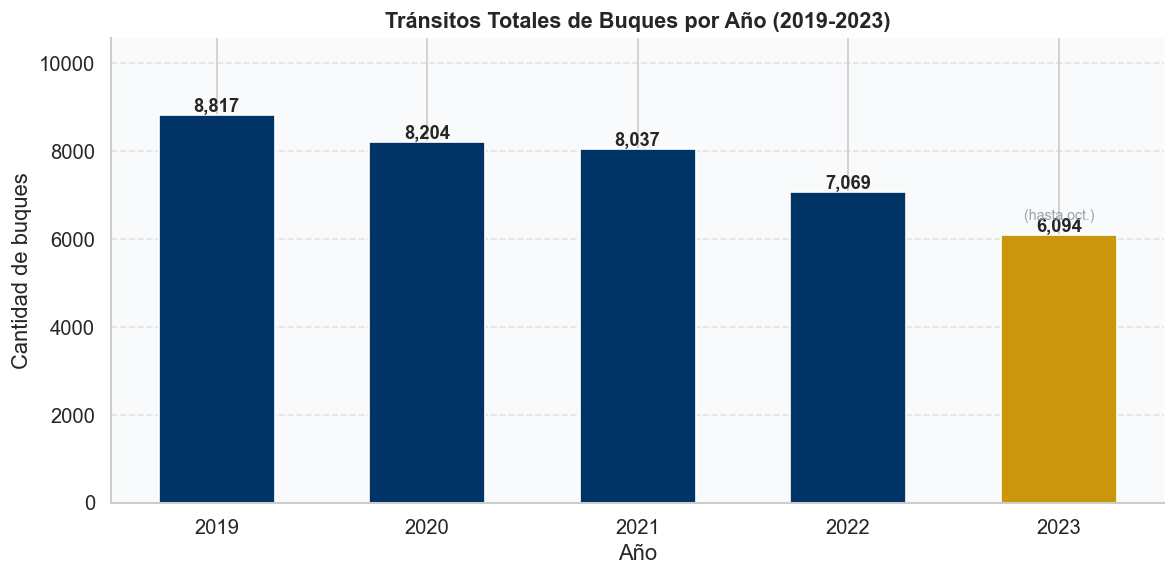

In [58]:
anual = df.groupby('anio').agg(
    barcos   = ('imo', 'count'),
    espera   = ('waiting_time', 'mean'),
    transito = ('transit_time', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

colores = [C_BLUE if a != 2023 else C_GOLD for a in anual['anio']]
bars = ax.bar(anual['anio'], anual['barcos'],
              color=colores, edgecolor='white', width=0.55)

for bar, row in zip(bars, anual.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{row.barcos:,}', ha='center', fontsize=11, fontweight='bold')

# Nota 2023
val_2023 = anual[anual['anio']==2023]['barcos'].values[0]
ax.text(2023, val_2023 + 350, '(hasta oct.)', ha='center', fontsize=8.5, color=C_GRAY)

ax.set_title('Tránsitos Totales de Buques por Año (2019-2023)')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de buques')
ax.set_xticks(anual['anio'])
ax.set_ylim(0, anual['barcos'].max() * 1.20)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz1_transitos_anuales.png', dpi=150, bbox_inches='tight')
plt.show()


En este gráfico se puede ver que la cantidad de buques que transitaron el Canal se mantuvo relativamente estable con una leve caída, y en 2023 los datos solo llegan hasta octubre, por lo que ese total no es directamente comparable con los demás años

### Gráfico 2. Estacionalidad Mensual del Tráfico

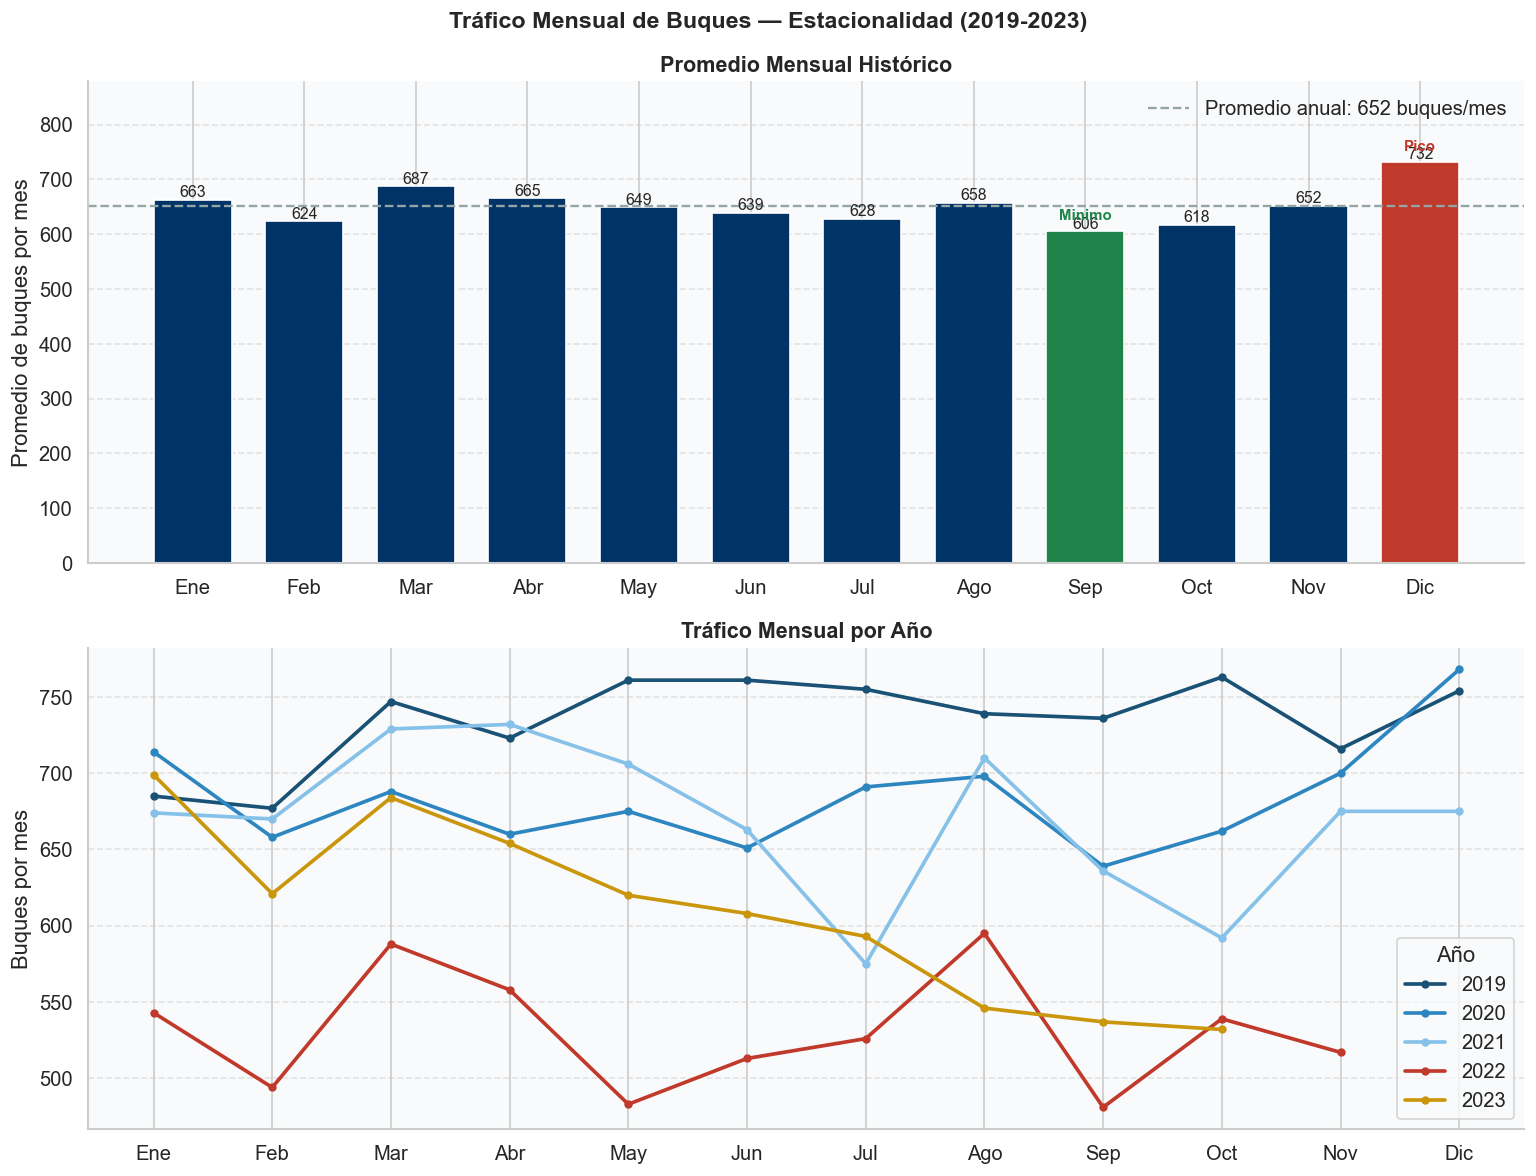

In [96]:
mensual = df.groupby(['anio', 'mes'])['imo'].count().reset_index()
mensual.columns = ['Anio', 'Mes', 'Barcos']
mes_nombres = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']

# Excluir anomalía dic-2022 para el promedio histórico
sin_anomalia = mensual[~((mensual['Anio']==2022) & (mensual['Mes']==12))]
prom_mes = sin_anomalia.groupby('Mes')['Barcos'].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle('Tráfico Mensual de Buques — Estacionalidad (2019-2023)',
             fontsize=14, fontweight='bold')

# ── Panel 1: promedio histórico ───────────────────────────────────────
colores_mes = [C_RED   if v == prom_mes['Barcos'].max()
               else (C_GREEN if v == prom_mes['Barcos'].min() else C_BLUE)
               for v in prom_mes['Barcos']]
bars = axes[0].bar(prom_mes['Mes'], prom_mes['Barcos'],
                   color=colores_mes, edgecolor='white', width=0.7)
for bar, val in zip(bars, prom_mes['Barcos']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{val:.0f}', ha='center', fontsize=9.5)
axes[0].axhline(prom_mes['Barcos'].mean(), color=C_GRAY,
                linestyle='--', linewidth=1.4,
                label=f'Promedio anual: {prom_mes["Barcos"].mean():.0f} buques/mes')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(mes_nombres)
axes[0].set_title('Promedio Mensual Histórico')
axes[0].set_ylabel('Promedio de buques por mes')
axes[0].set_ylim(0, prom_mes['Barcos'].max() * 1.20)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5); axes[0].set_axisbelow(True)
axes[0].legend(frameon=False)

# Anotación mes pico y mínimo
idx_max = prom_mes['Barcos'].idxmax()
idx_min = prom_mes['Barcos'].idxmin()
axes[0].text(prom_mes.loc[idx_max,'Mes'], prom_mes.loc[idx_max,'Barcos'] + 20,
             'Pico', ha='center', fontsize=9, color=C_RED, fontweight='bold')
axes[0].text(prom_mes.loc[idx_min,'Mes'], prom_mes.loc[idx_min,'Barcos'] + 20,
             'Minimo', ha='center', fontsize=9, color=C_GREEN, fontweight='bold')

# ── Panel 2: líneas por año ───────────────────────────────────────────
colores_anio = {2019:'#1A5276', 2020:'#2E86C1', 2021:'#85C1E9',
                2022:C_RED, 2023:C_GOLD}
for anio, grp in mensual.groupby('Anio'):
    grp = grp[grp['Mes'] <= 10] if anio == 2023 else grp
    grp = grp[~((grp['Anio']==2022) & (grp['Mes']==12))]
    grp = grp.sort_values('Mes')
    axes[1].plot(grp['Mes'], grp['Barcos'],
                 color=colores_anio.get(anio, C_GRAY),
                 linewidth=2.2, marker='o', markersize=4,
                 label=str(anio))
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(mes_nombres)
axes[1].set_title('Tráfico Mensual por Año')
axes[1].set_ylabel('Buques por mes')
axes[1].legend(title='Año', frameon=True)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz2_trafico_mensual.png', dpi=150, bbox_inches='tight')
plt.show()


El gráfico muestra que históricamente los meses de marzo, abril y diciembre concentran el mayor número de tránsitos, mientras que febrero, septiembre y octubre son los meses más bajos. 

Al comparar los años 2022 presenta valores más bajos en la mayoría de los meses.

Parece haber cierta estacionalidad, especialmente viendo los primeros meses de cada año, aunque no se ve un comportamiento similar entre todos los años.

### Gráfico 3. Estacionalidad Mensual de los Tiempos de Espera y Tránsito

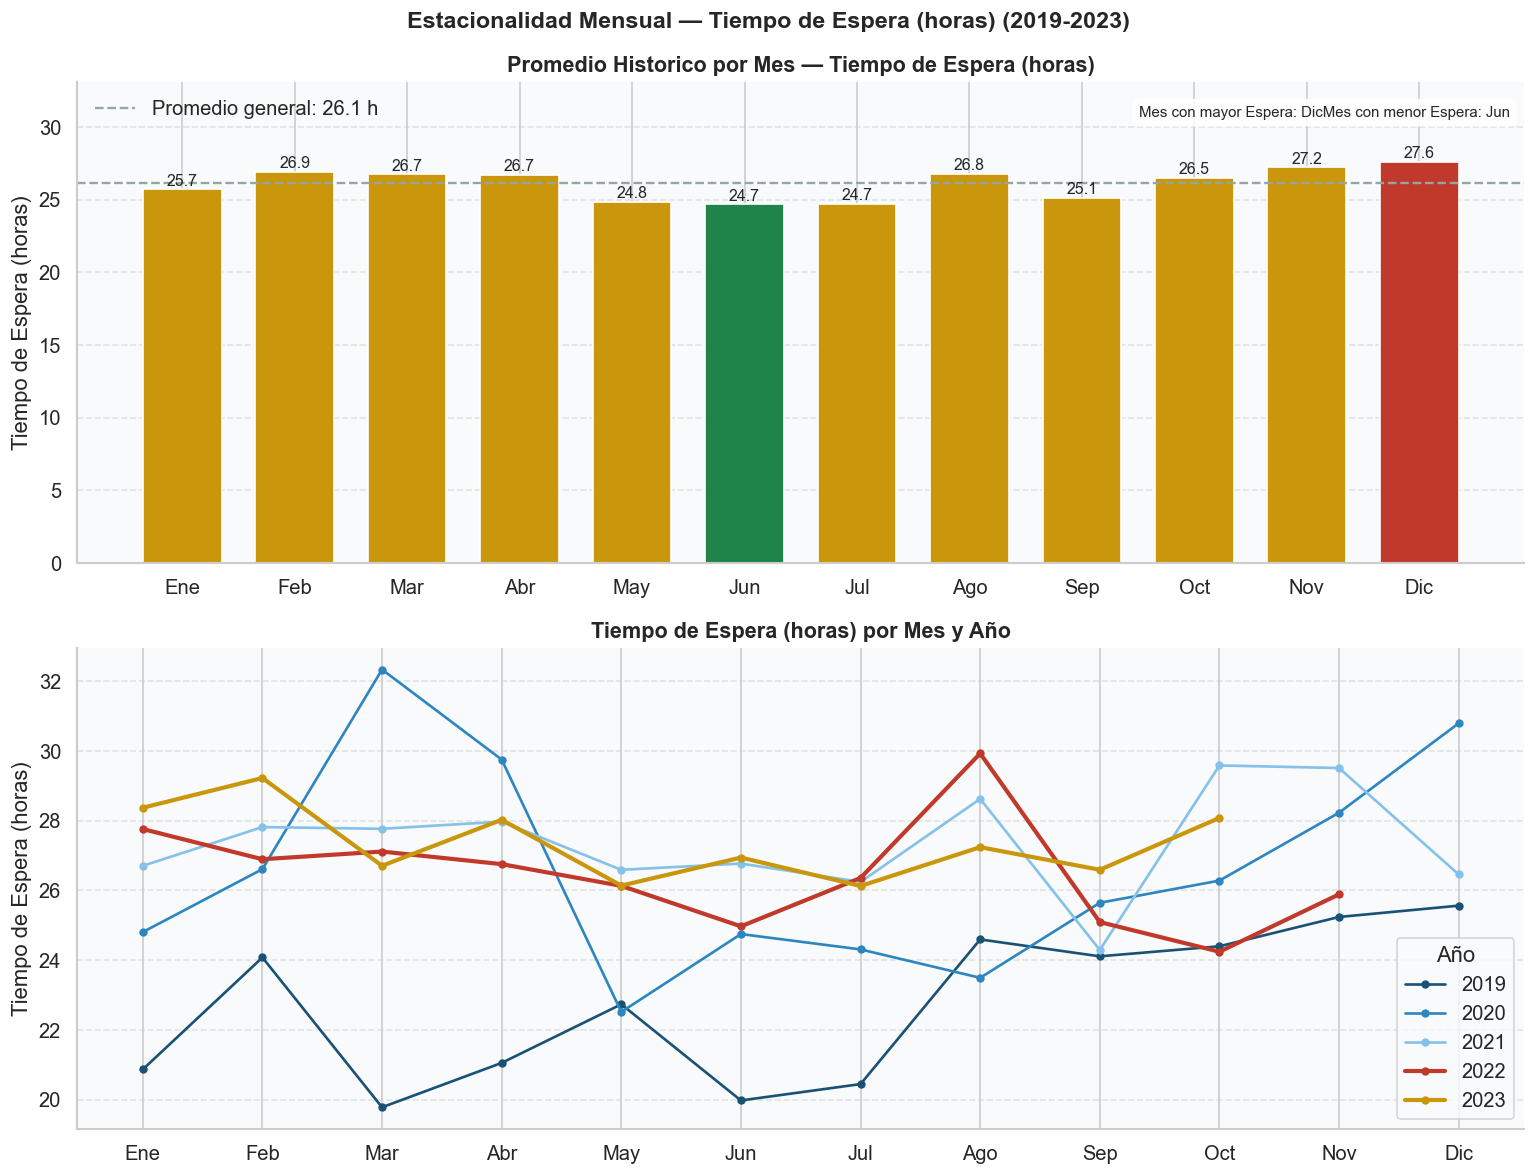

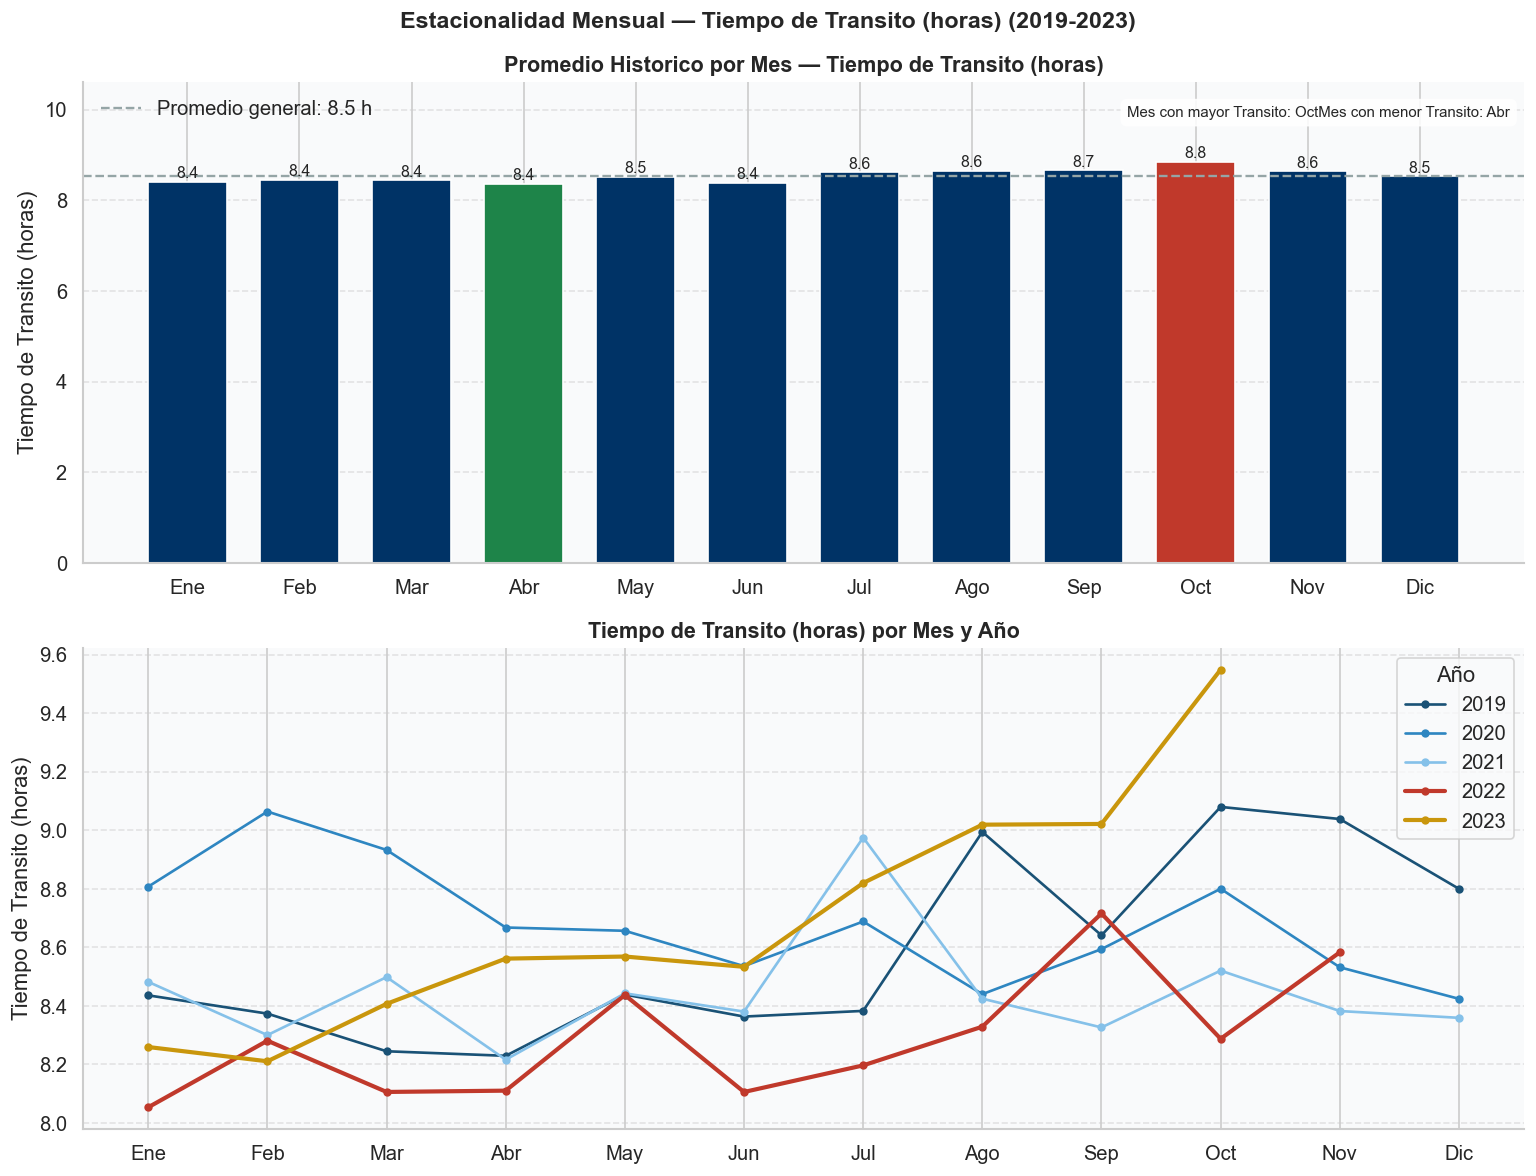

In [97]:
mes_nombres = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']

colores_anio = {2019:'#1A5276', 2020:'#2E86C1', 2021:'#85C1E9',
                2022:C_RED, 2023:C_GOLD}

# Excluir anomalía dic-2022
df_clean = df[~((df['anio']==2022) & (df['mes']==12))]

for col, label, color_prom, fname in [
    ('waiting_time',  'Tiempo de Espera (horas)',   C_GOLD, 'viz2b_espera_mensual.png'),
    ('transit_time',  'Tiempo de Transito (horas)',  C_BLUE, 'viz2c_transito_mensual.png'),
]:
    mensual_t = df_clean.groupby(['anio','mes'])[col].mean().reset_index()
    mensual_t.columns = ['Anio','Mes', label]
    prom_mes  = mensual_t.groupby('Mes')[label].mean().reset_index()

    fig, axes = plt.subplots(2, 1, figsize=(13, 10))
    fig.suptitle(f'Estacionalidad Mensual — {label} (2019-2023)',
                 fontsize=14, fontweight='bold')

    # ── Panel 1: promedio histórico por mes ────────────────────────
    idx_max = prom_mes[label].idxmax()
    idx_min = prom_mes[label].idxmin()
    colores_mes = [C_RED   if i == idx_max
                   else (C_GREEN if i == idx_min else color_prom)
                   for i in prom_mes.index]

    bars = axes[0].bar(prom_mes['Mes'], prom_mes[label],
                       color=colores_mes, edgecolor='white', width=0.7)
    for bar, val in zip(bars, prom_mes[label]):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + prom_mes[label].max() * 0.01,
                     f'{val:.1f}', ha='center', fontsize=9.5)

    prom_general = prom_mes[label].mean()
    axes[0].axhline(prom_general, color=C_GRAY, linestyle='--', linewidth=1.4,
                    label=f'Promedio general: {prom_general:.1f} h')
    axes[0].set_xticks(range(1,13))
    axes[0].set_xticklabels(mes_nombres)
    axes[0].set_title(f'Promedio Historico por Mes — {label}')
    axes[0].set_ylabel(label)
    axes[0].set_ylim(0, prom_mes[label].max() * 1.20)
    axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
    axes[0].set_axisbelow(True)
    axes[0].legend(frameon=False)

    mes_pico = mes_nombres[idx_max]
    mes_min  = mes_nombres[idx_min]
    axes[0].text(0.99, 0.95,f'Mes con mayor {label.split()[2]}: {mes_pico}'
                 f'Mes con menor {label.split()[2]}: {mes_min}',
                 transform=axes[0].transAxes, ha='right', va='top',
                 fontsize=9, bbox=dict(boxstyle='round,pad=0.4',
                                       facecolor='white', alpha=0.85))

    # ── Panel 2: líneas por año ────────────────────────────────────
    for anio, grp in mensual_t.groupby('Anio'):
        grp = grp[grp['Mes'] <= 10] if anio == 2023 else grp
        grp = grp.sort_values('Mes')
        lw  = 2.5 if anio in [2022, 2023] else 1.6
        axes[1].plot(grp['Mes'], grp[label],
                     color=colores_anio.get(anio, C_GRAY),
                     linewidth=lw, marker='o', markersize=4,
                     label=str(anio))

    axes[1].set_xticks(range(1,13))
    axes[1].set_xticklabels(mes_nombres)
    axes[1].set_title(f'{label} por Mes y Año')
    axes[1].set_ylabel(label)
    axes[1].legend(title='Año', frameon=True)
    axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)
    axes[1].set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


Para el tiempo de espera, se observa que los meses de febrero, noviembre y diciembre tienden a tener los promedios más altos, mientras que mayo, junio y julio muestran los más bajos. Al ver las líneas por año, 2023 tiene tiempos de espera consistentemente más altos que los años anteriores en casi todos los meses. 

Para el tiempo de tránsito, el comportamiento es más estable: no varía mucho entre meses ni entre años, lo que indica que el proceso de cruzar el Canal toma un tiempo similar independientemente de la época del año. Viendo la linea de tiempo, parece que en la mayoría de los años se tiende a demorar más al final del año. Puede que los gráficos de 2020 esten afectando la media. 

### Gráfico 4. Distribución del Tráfico Diario

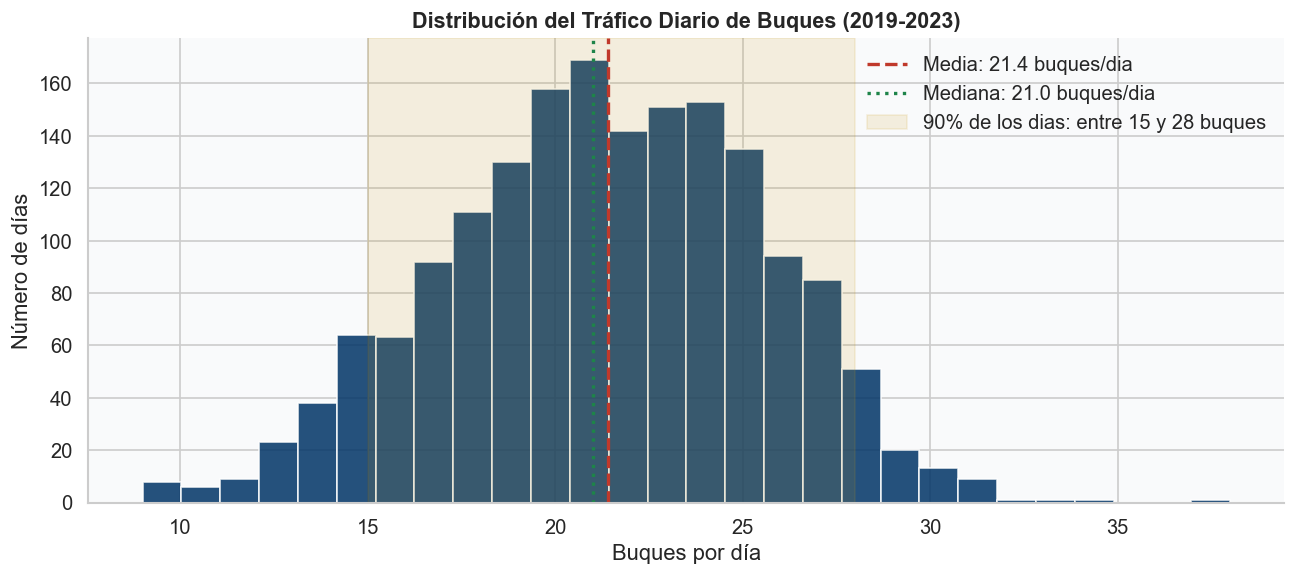

Minimo: 9 buques/dia  |  Maximo: 38 buques/dia
El 90% de los dias opera entre 15 y 28 buques.


In [98]:
diario = df.groupby('fecha')['imo'].count().reset_index()
diario.columns = ['Fecha', 'Barcos']
diario['Fecha'] = pd.to_datetime(diario['Fecha'])

# Excluir anomalía dic-2022
diario_clean = diario[~((diario['Fecha'].dt.year==2022) &
                        (diario['Fecha'].dt.month==12))]

media   = diario_clean['Barcos'].mean()
mediana = diario_clean['Barcos'].median()
p05     = diario_clean['Barcos'].quantile(0.05)
p95     = diario_clean['Barcos'].quantile(0.95)

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(diario_clean['Barcos'], bins=28,
        color=C_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(media,   color=C_RED,   linestyle='--', linewidth=2,
           label=f'Media: {media:.1f} buques/dia')
ax.axvline(mediana, color=C_GREEN, linestyle=':',  linewidth=2,
           label=f'Mediana: {mediana:.1f} buques/dia')
ax.axvspan(p05, p95, alpha=0.12, color=C_GOLD,
           label=f'90% de los dias: entre {p05:.0f} y {p95:.0f} buques')

ax.set_title('Distribución del Tráfico Diario de Buques (2019-2023)')
ax.set_xlabel('Buques por día')
ax.set_ylabel('Número de días')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('viz3_trafico_diario.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Minimo: {diario_clean['Barcos'].min()} buques/dia  |  Maximo: {diario_clean['Barcos'].max()} buques/dia")
print(f"El 90% de los dias opera entre {p05:.0f} y {p95:.0f} buques.")


La distribución muestra que la mayoría de los días el Canal registra entre 15 y 28 buques en tránsito, con una media de aproximadamente 21 buques por día. La distribución es bastante simétrica. 

---
## Bloque 2 — Nuevas Variables Incorporadas: Clima y Lago Gatún

Se presentan los datos del Lago Gatún, y se analiza su relación de las variables climaticas nuevas 
con los tiempos operativos del Canal.

¿Agregar datos de clima y del lago mejora la capacidad
predictiva del modelo?


### Gráfico 5.  Nivel del Lago Gatún

Meses bajo el promedio historico por año:
  2019: 12/12 meses bajo referencia  |  nivel promedio anual = 82.00 ft
  2020:  6/12 meses bajo referencia  |  nivel promedio anual = 84.09 ft
  2021:  0/12 meses bajo referencia  |  nivel promedio anual = 86.50 ft
  2022:  0/12 meses bajo referencia  |  nivel promedio anual = 86.83 ft
  2023:  8/12 meses bajo referencia  |  nivel promedio anual = 81.84 ft


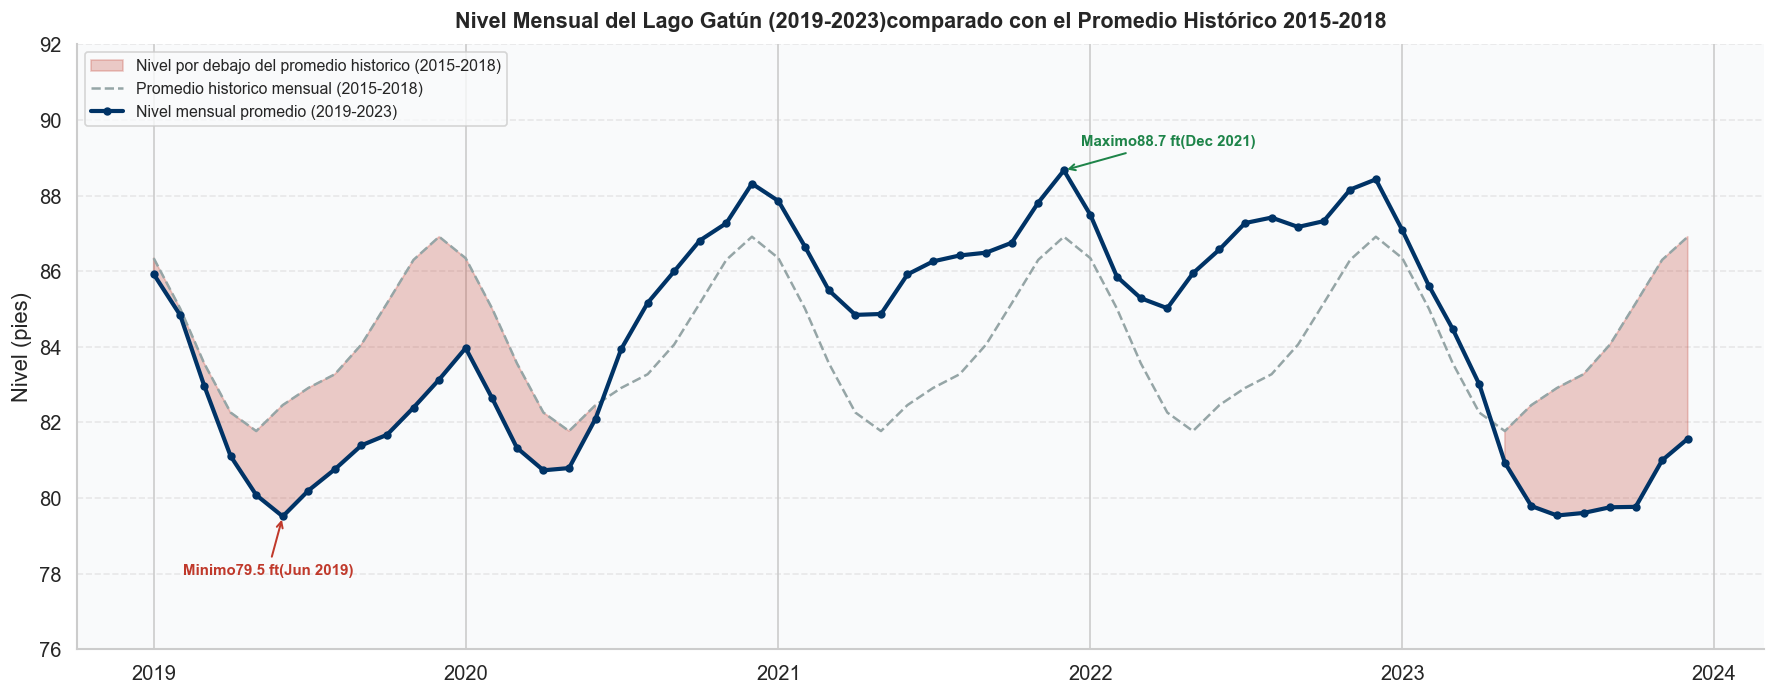

In [99]:
# Cargar datos del lago Gatún
gatun = pd.read_csv(os.path.join(DATA_DIR, 'Gatun_Lake_Water_Level_History.csv'), sep=',')
gatun['DATE_LOG'] = pd.to_datetime(gatun['DATE_LOG'])
gatun = gatun.rename(columns={'GATUN_LAKE_LEVEL(FEET)': 'Nivel'})
gatun['anio'] = gatun['DATE_LOG'].dt.year
gatun['mes']  = gatun['DATE_LOG'].dt.month

# Referencia histórica: promedio mensual 2015-2018
base = (gatun[gatun['anio'].between(2015, 2018)]
        .groupby('mes')['Nivel'].mean()
        .reset_index()
        .rename(columns={'Nivel': 'nivel_base'}))

# Promedio mensual período de estudio
mensual_g = (gatun[gatun['anio'].between(2019, 2023)]
             .groupby(['anio','mes'])['Nivel'].mean()
             .reset_index())
mensual_g = mensual_g.merge(base, on='mes')
mensual_g['fecha'] = pd.to_datetime(
    mensual_g[['anio','mes']].rename(columns={'anio':'year','mes':'month'}).assign(day=1))
mensual_g = mensual_g.sort_values('fecha')
mensual_g['bajo_historico'] = mensual_g['Nivel'] < mensual_g['nivel_base']

fig, ax = plt.subplots(figsize=(15, 6))

# Zona roja: meses bajo el promedio histórico
ax.fill_between(mensual_g['fecha'],
                mensual_g['nivel_base'], mensual_g['Nivel'],
                where=mensual_g['bajo_historico'],
                color=C_RED, alpha=0.25,
                label='Nivel por debajo del promedio historico (2015-2018)')

# Línea de referencia histórica
ax.plot(mensual_g['fecha'], mensual_g['nivel_base'],
        color=C_GRAY, linewidth=1.5, linestyle='--',
        label='Promedio historico mensual (2015-2018)')

# Línea principal
ax.plot(mensual_g['fecha'], mensual_g['Nivel'],
        color=C_BLUE, linewidth=2.5, marker='o', markersize=4,
        label='Nivel mensual promedio (2019-2023)')

# Anotar mínimo absoluto
idx_min = mensual_g['Nivel'].idxmin()
row_min = mensual_g.loc[idx_min]
ax.annotate(f"Minimo{row_min['Nivel']:.1f} ft({row_min['fecha'].strftime('%b %Y')})",
            xy=(row_min['fecha'], row_min['Nivel']),
            xytext=(-60, -35), textcoords='offset points',
            fontsize=9, color=C_RED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_RED, lw=1.2))

# Anotar máximo absoluto
idx_max = mensual_g['Nivel'].idxmax()
row_max = mensual_g.loc[idx_max]
ax.annotate(f"Maximo{row_max['Nivel']:.1f} ft({row_max['fecha'].strftime('%b %Y')})",
            xy=(row_max['fecha'], row_max['Nivel']),
            xytext=(10, 15), textcoords='offset points',
            fontsize=9, color=C_GREEN, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.2))

ax.set_title('Nivel Mensual del Lago Gatún (2019-2023)comparado con el Promedio Histórico 2015-2018',
             pad=10)
ax.set_ylabel('Nivel (pies)')
ax.set_xlabel('')
ax.legend(loc='upper left', frameon=True, fontsize=9.5)
ax.set_ylim(76, 92)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# Resumen por año
print("Meses bajo el promedio historico por año:")
for anio, grp in mensual_g.groupby('anio'):
    n = grp['bajo_historico'].sum()
    prom = grp['Nivel'].mean()
    print(f"  {anio}: {n:>2}/12 meses bajo referencia  |  nivel promedio anual = {prom:.2f} ft")

plt.tight_layout()
plt.savefig('viz4_lago_gatun.png', dpi=150, bbox_inches='tight')
plt.show()


Se puede observar que el nivel del lago sigue un patrón estacional claro: tiende a bajar durante el primer semestre (temporada seca) y a recuperarse en el segundo semestre (temporada lluviosa). Los años 2021 y 2022 tuvieron niveles notablemente altos, superando la referencia histórica en casi todos los meses. Por el contrario, 2019 y 2023 presentaron niveles por debajo del promedio histórico durante varios meses consecutivos, especialmente en el segundo semestre. 

### Gráfico 6. Correlación de Variables con los Tiempos Operativos

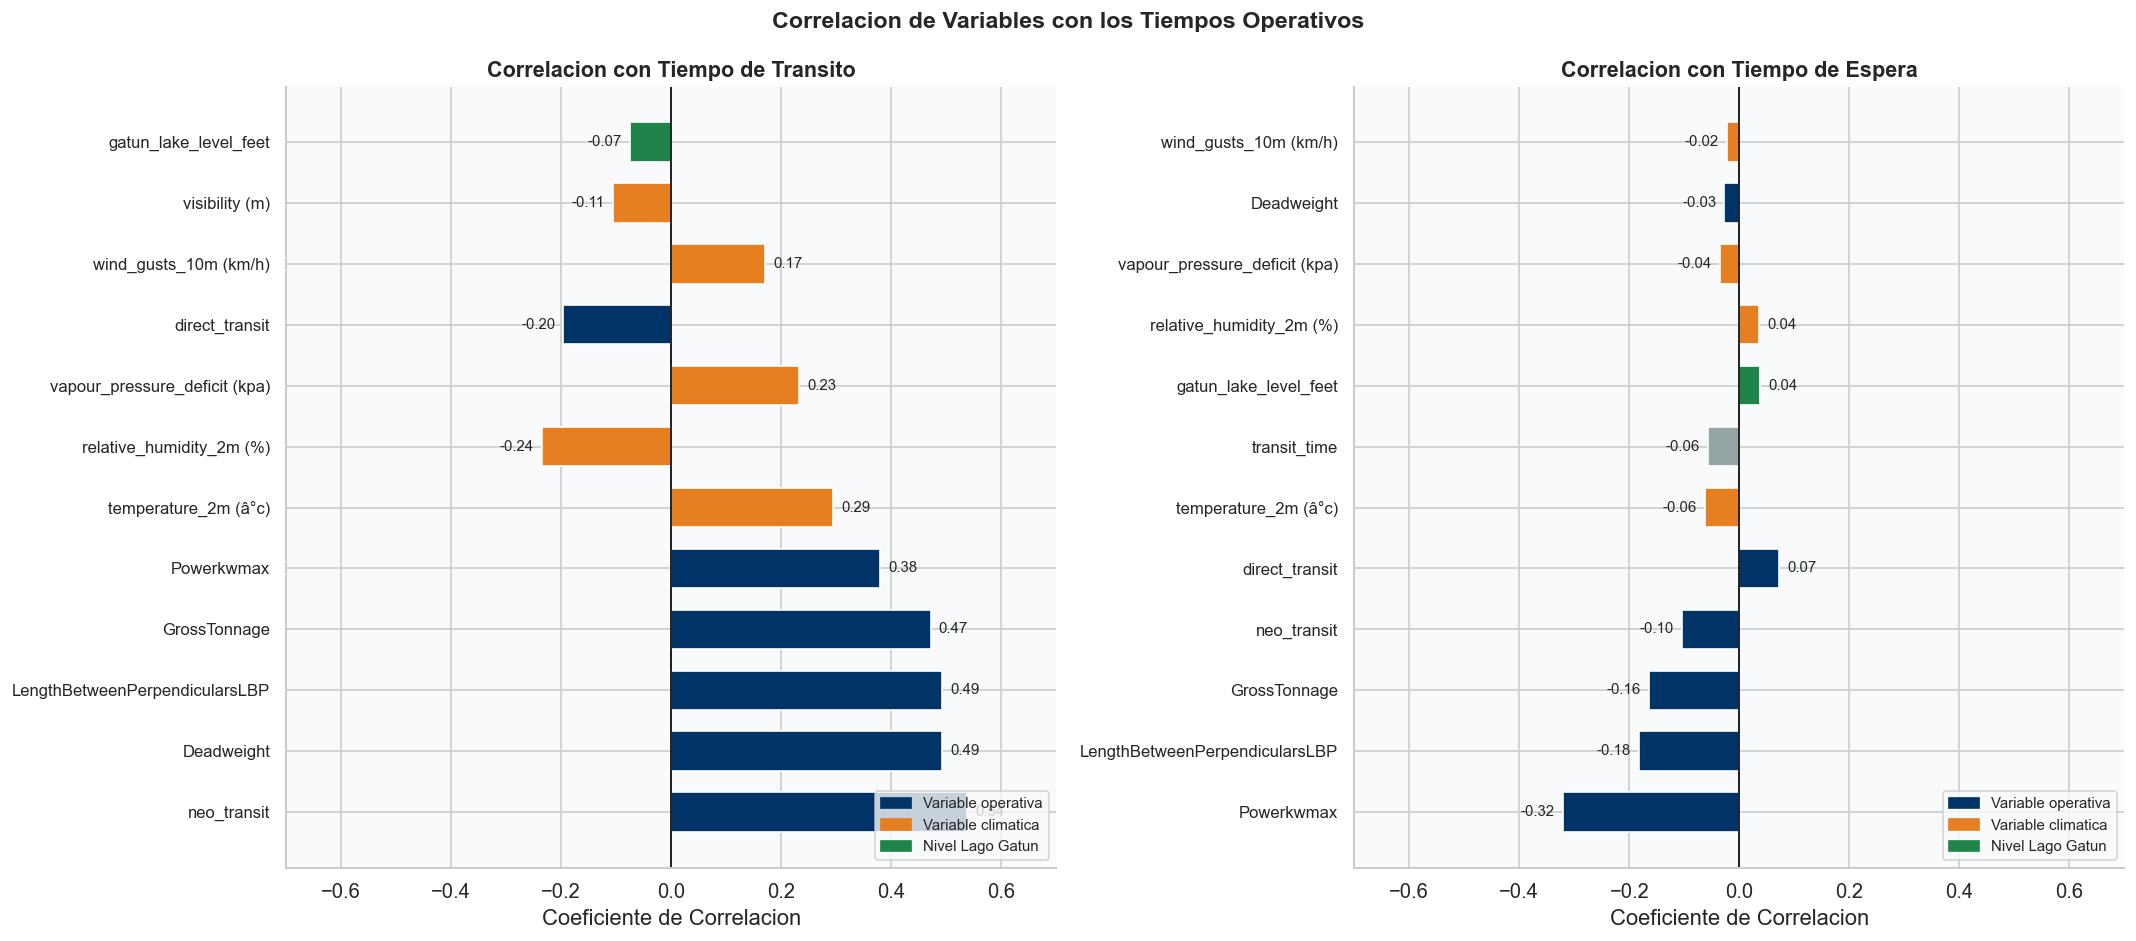

HALLAZGOS DE CORRELACION:

Top variables para TRANSIT TIME:
  neo_transit                              r = +0.537  [buque]
  Deadweight                               r = +0.493  [buque]
  LengthBetweenPerpendicularsLBP           r = +0.492  [buque]
  GrossTonnage                             r = +0.471  [buque]
  Powerkwmax                               r = +0.379  [buque]

Top variables para WAITING TIME:
  Powerkwmax                               r = -0.320  [buque]
  LengthBetweenPerpendicularsLBP           r = -0.182  [buque]
  GrossTonnage                             r = -0.164  [buque]
  neo_transit                              r = -0.105  [buque]
  direct_transit                           r = +0.072  [buque]


In [100]:
# Variables por categoria (segun su origen en el dataset)
vars_buque  = ['neo_transit', 'direct_transit', 'LengthBetweenPerpendicularsLBP',
               'GrossTonnage', 'Deadweight', 'Powerkwmax']
vars_clima  = [c for c in df.columns if any(k in c for k in
               ['temperature','precipitation','humidity','wind','cloud','visibility','vapour'])]
vars_lago   = [c for c in df.columns if 'gatun' in c.lower() and df[c].dtype != 'object']

# Calcular correlaciones
num_cols = vars_buque + vars_clima + vars_lago
corr = df[num_cols + ['transit_time','waiting_time']].corr()

# Asignar color por origen
def color_var(v):
    if v in vars_buque:  return C_BLUE
    if v in vars_clima:  return C_ORANGE
    if v in vars_lago:   return C_GREEN
    return C_GRAY

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Correlacion de Variables con los Tiempos Operativos', fontsize=14, fontweight='bold')

top_n = 12

for ax, target, title in [
    (axes[0], 'transit_time',  'Correlacion con Tiempo de Transito'),
    (axes[1], 'waiting_time',  'Correlacion con Tiempo de Espera'),
]:
    serie = corr[target].drop(target)
    top   = serie.abs().sort_values(ascending=False).head(top_n)
    vals  = serie[top.index]
    colors = [color_var(v) for v in vals.index]

    bars = ax.barh(range(len(vals)), vals.values,
                   color=colors, edgecolor='white', height=0.65)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=10)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlim(-0.7, 0.7)
    ax.set_xlabel('Coeficiente de Correlacion')
    ax.set_title(title)

    # Etiquetas de valor
    for bar, val in zip(bars, vals.values):
        xpos = val + 0.015 if val >= 0 else val - 0.015
        ha   = 'left' if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha=ha, fontsize=9)

    # Leyenda de colores
    leyenda = [
        mpatches.Patch(color=C_BLUE,   label='Variable operativa'),
        mpatches.Patch(color=C_ORANGE, label='Variable climatica'),
        mpatches.Patch(color=C_GREEN,  label='Nivel Lago Gatun'),
    ]
    ax.legend(handles=leyenda, frameon=True, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('viz5_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen de hallazgos
print("HALLAZGOS DE CORRELACION:")
print()
print("Top variables para TRANSIT TIME:")
top_t = corr['transit_time'].drop('transit_time').abs().sort_values(ascending=False).head(5)
for var, val in top_t.items():
    origen = 'buque' if var in vars_buque else ('clima' if var in vars_clima else 'lago')
    print(f"  {var:<40} r = {corr['transit_time'][var]:+.3f}  [{origen}]")
print()
print("Top variables para WAITING TIME:")
top_w = corr['waiting_time'].drop('waiting_time').abs().sort_values(ascending=False).head(5)
for var, val in top_w.items():
    origen = 'buque' if var in vars_buque else ('clima' if var in vars_clima else 'lago')
    print(f"  {var:<40} r = {corr['waiting_time'][var]:+.3f}  [{origen}]")


Para el tiempo de tránsito, las variables con mayor correlación son las del buque: el tipo de esclusa (neo_transit), el peso muerto (Deadweight) y la eslora (LBP). Entre las variables nuevas incorporadas en este avance, la temperatura es la que mayor relación muestra con el tiempo de tránsito (r = 0.29). Para el tiempo de espera, las correlaciones son más bajas en general, lo que sugiere que este tiempo depende de factores más complejos que no se capturan completamente con una relación lineal. Las variables de clima y el nivel del lago tienen correlaciones bajas a nivel individual, pero podrían ser útiles en combinación dentro de un modelo no lineal como Random Forest o XGBoost.

### Gráfico 7. Nivel del Lago Gatún vs Tiempos Operativos a lo Largo del Tiempo

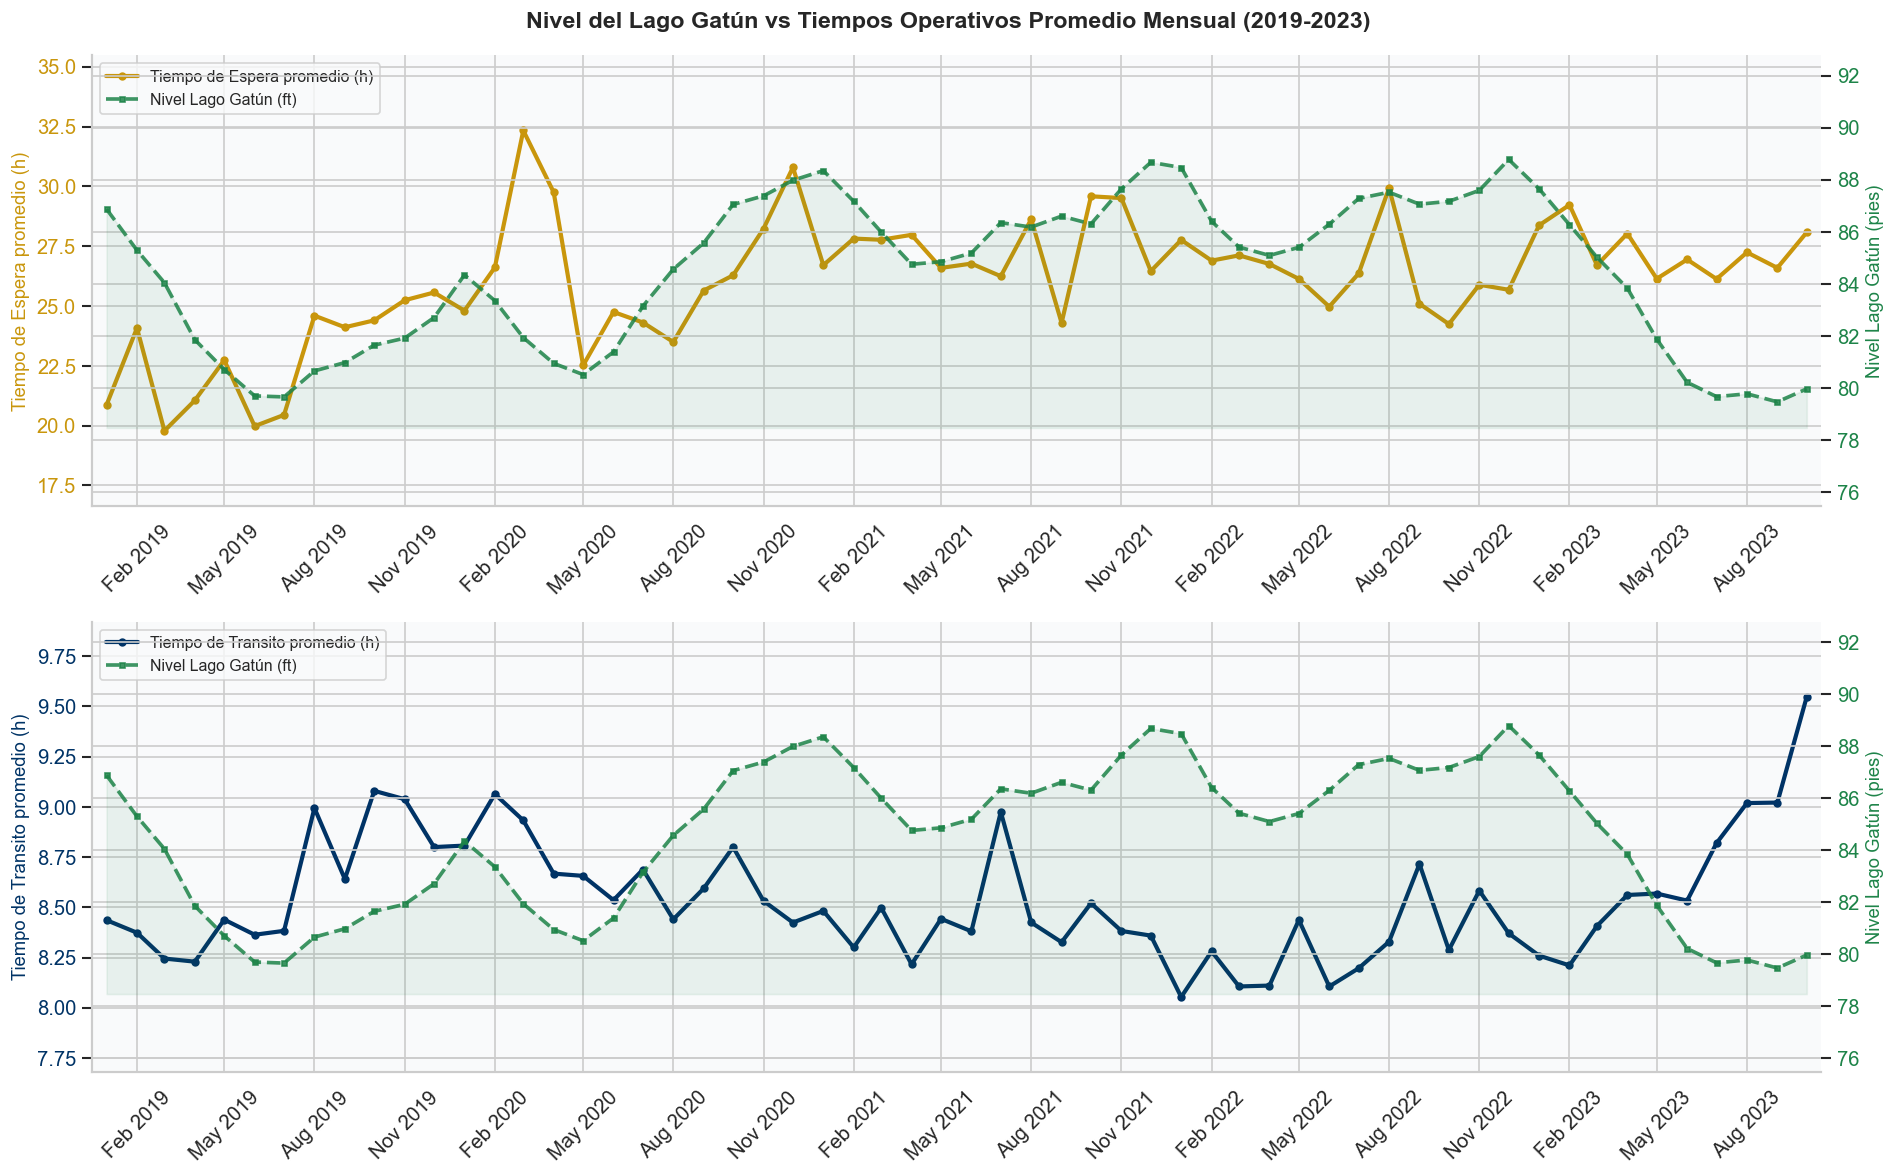

In [125]:
import matplotlib.dates as mdates

# ── Preparar promedios mensuales ───────────────────────────────────────
df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])
df['anio'] = df['time_at_entrance'].dt.year
df['mes']  = df['time_at_entrance'].dt.month

lago_col = [c for c in df.columns
            if 'gatun' in c.lower() and df[c].dtype != 'object'][0]

monthly = (df.groupby(['anio', 'mes'])
             .agg(espera   = ('waiting_time', 'mean'),
                  transito = ('transit_time', 'mean'),
                  lago     = (lago_col, 'mean'))
             .reset_index())

monthly['fecha'] = pd.to_datetime(
    monthly[['anio', 'mes']]
    .rename(columns={'anio': 'year', 'mes': 'month'})
    .assign(day=1)
)
monthly = monthly.sort_values('fecha').reset_index(drop=True)

# ── Figura: 2 paneles apilados ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Nivel del Lago Gatún vs Tiempos Operativos Promedio Mensual (2019-2023)',
             fontsize=14, fontweight='bold')

for ax, col, label_y, color_y, r_val in [
    (ax1, 'espera',   'Tiempo de Espera promedio (h)',   C_GOLD, 0.32),
    (ax2, 'transito', 'Tiempo de Transito promedio (h)', C_BLUE, -0.53),
]:
    # ── Eje Y izquierdo: tiempo operativo ──────────────────────────
    ax.plot(monthly['fecha'], monthly[col],
            color=color_y, linewidth=2.5,
            marker='o', markersize=4, label=label_y)
    ax.set_ylabel(label_y, color=color_y, fontsize=11)
    ax.tick_params(axis='y', labelcolor=color_y)
    margen = (monthly[col].max() - monthly[col].min()) * 0.25
    ax.set_ylim(monthly[col].min() - margen,
                monthly[col].max() + margen)

    # ── Eje Y derecho: nivel del lago ──────────────────────────────
    ax_r = ax.twinx()
    ax_r.plot(monthly['fecha'], monthly['lago'],
              color=C_GREEN, linewidth=2.2, linestyle='--',
              marker='s', markersize=3, alpha=0.85,
              label='Nivel Lago Gatún (ft)')
    ax_r.fill_between(monthly['fecha'],
                      monthly['lago'],
                      monthly['lago'].min() - 1,
                      color=C_GREEN, alpha=0.08)
    ax_r.set_ylabel('Nivel Lago Gatún (pies)', color=C_GREEN, fontsize=11)
    ax_r.tick_params(axis='y', labelcolor=C_GREEN)
    ax_r.set_ylim(monthly['lago'].min() - 4,
                  monthly['lago'].max() + 4)

    # ── Eje X: etiquetas mes-año ───────────────────────────────────
    ax.set_xlim(monthly['fecha'].min() - pd.DateOffset(days=15),
                monthly['fecha'].max() + pd.DateOffset(days=15))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)

    # ── Leyenda y correlación ──────────────────────────────────────
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_r.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2,
              loc='upper left', frameon=True, fontsize=9.5)
    '''ax.text(0.99, 0.97,
            f'Correlacion mensual  r = {r_val:+.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='white', alpha=0.92))
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)'''

plt.tight_layout()
plt.savefig('viz5b_lago_vs_tiempos_serie.png', dpi=150, bbox_inches='tight')
plt.show()


Se intenta buscar una relación entre los comportamientos de los niveles del lago Gatún y los tiempos de espera y tiempos de tránsito. Aunque en algunas secciones se puede notar como los tiempos de tránsito son menores cuando los niveles de agua del lago Gatún son superiores.  

### Gráfico 7. Evolución Anual de los Tiempos de Espera y Tránsito

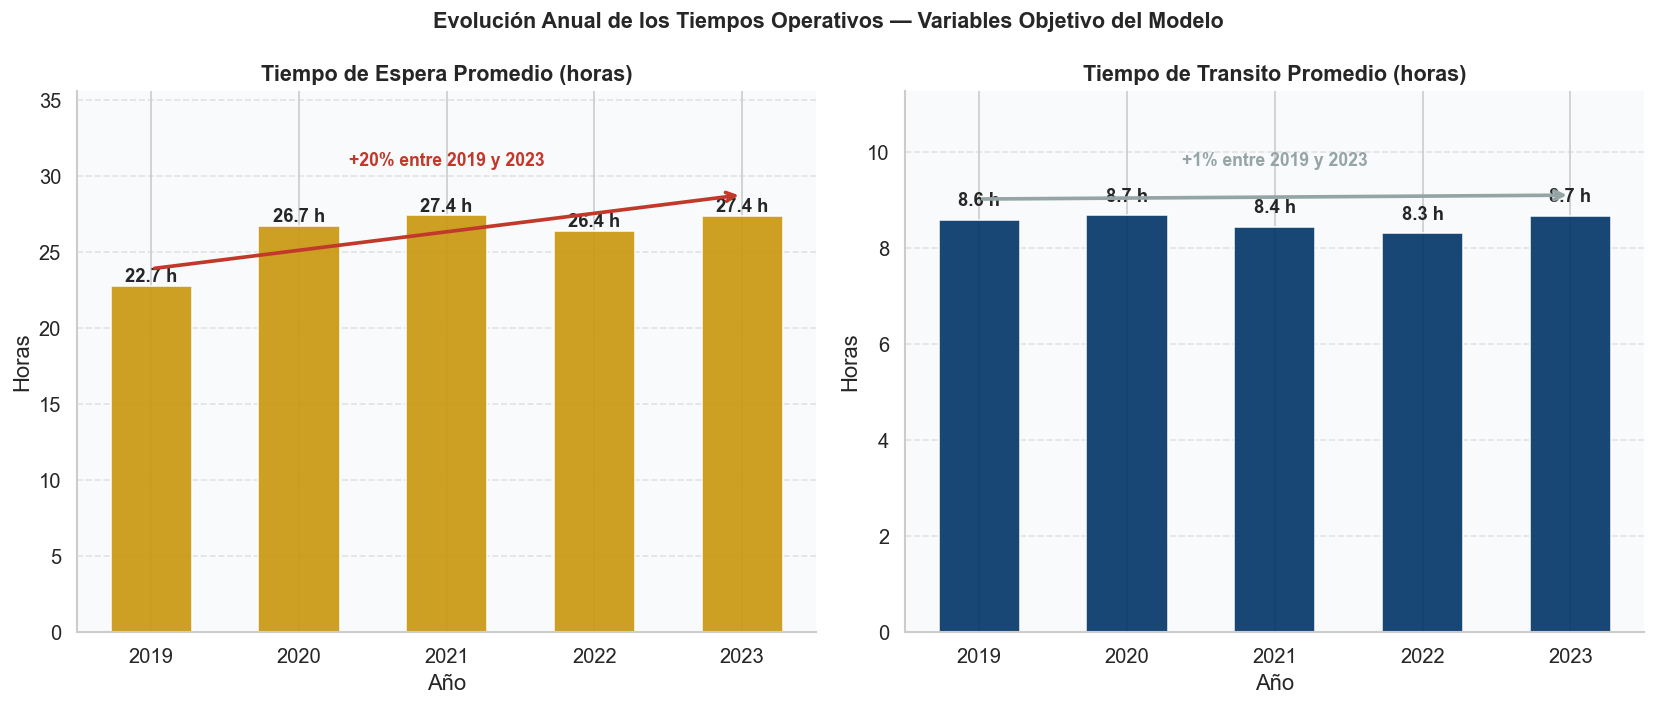

In [126]:
por_anio = df.groupby('anio').agg(
    espera   = ('waiting_time', 'mean'),
    transito = ('transit_time', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evolución Anual de los Tiempos Operativos — Variables Objetivo del Modelo',
             fontsize=13, fontweight='bold')

for ax, col, label, color in [
    (axes[0], 'espera',   'Tiempo de Espera Promedio (horas)',   C_GOLD),
    (axes[1], 'transito', 'Tiempo de Transito Promedio (horas)', C_BLUE),
]:
    bars = ax.bar(por_anio['anio'], por_anio[col],
                  color=color, edgecolor='white', width=0.55, alpha=0.9)
    for bar, val in zip(bars, por_anio[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f} h', ha='center', fontsize=11, fontweight='bold')

    # Flecha de tendencia 2019-2023
    y_ini = por_anio.iloc[0][col]
    y_fin = por_anio.iloc[-1][col]
    cambio = (y_fin / y_ini - 1) * 100
    color_flecha = C_RED if cambio > 5 else (C_GREEN if cambio < -5 else C_GRAY)
    ax.annotate('',
        xy=(por_anio['anio'].iloc[-1], y_fin * 1.05),
        xytext=(por_anio['anio'].iloc[0], y_ini * 1.05),
        arrowprops=dict(arrowstyle='->', color=color_flecha, lw=2.2))
    ax.text(por_anio['anio'].mean(),
            max(por_anio[col]) * 1.12,
            f'{cambio:+.0f}% entre 2019 y 2023',
            ha='center', fontsize=10.5,
            color=color_flecha, fontweight='bold')

    ax.set_title(label)
    ax.set_xlabel('Año')
    ax.set_ylabel('Horas')
    ax.set_xticks(por_anio['anio'])
    ax.set_ylim(0, por_anio[col].max() * 1.30)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz6_tiempos_anuales.png', dpi=150, bbox_inches='tight')
plt.show()


El tiempo de espera aumentó de forma sostenida entre 2019 y 2023, lo que indica que los buques están esperando cada vez más tiempo antes de ingresar a las esclusas. El tiempo de tránsito, en cambio, se mantiene estable alrededor del mismo valor en todos los años, lo que sugiere que el proceso de cruzar el Canal no ha cambiado significativamente. Esto indica que el problema principal está en la etapa de espera, no en el tránsito en sí, y que el tiempo de espera es la variable más importante y desafiante de predecir en este modelo.